In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

using CUDA
using cuDNN
CUDA.allowscalar(true)
println("CUDA.functional() = ", CUDA.functional())

using Random
using JLD2
using Flux
using Flux: onehotbatch, onecold
using MLUtils: DataLoader
using Statistics
using Printf
import StatisticalMeasures
using StatisticalMeasures: macro_avg, micro_avg
import StatisticalMeasures.ConfusionMatrices as CM

  Activating project at `~/Dokumente/BA2/notebooks/model_train`
Precompiling packages...
    635.0 ms  ✓ CUDA_Driver_jll
  1 dependency successfully precompiled in 1 seconds. 28 already precompiled.
Precompiling packages...
    981.9 ms  ✓ CUDA_Runtime_jll
  1 dependency successfully precompiled in 1 seconds. 30 already precompiled.
Precompiling packages...
    485.5 ms  ✓ ScientificTypesBase
    484.6 ms  ✓ EnumX
    674.0 ms  ✓ demumble_jll
    732.6 ms  ✓ JuliaNVTXCallbacks_jll
    750.0 ms  ✓ LibTracyClient_jll
    772.8 ms  ✓ NVTX_jll
    722.7 ms  ✓ WoodburyMatrices
    793.8 ms  ✓ LearnAPI
    807.7 ms  ✓ libpng_jll
    754.2 ms  ✓ BangBang → BangBangStaticArraysExt
    902.7 ms  ✓ Opus_jll
   1097.7 ms  ✓ FillArrays
   1059.4 ms  ✓ MLDataDevices
    566.6 ms  ✓ StatisticalTraits
    736.8 ms  ✓ AxisAlgorithms
    974.0 ms  ✓ KernelAbstractions → EnzymeExt
    809.8 ms  ✓ libsixel_jll
   1090.1 ms  ✓ Tracy
   1497.8 ms  ✓ LLVMExtra_jll
   1254.2 ms  ✓ NVTX
   2144.2 ms  ✓ Struct

CUDA.functional() = true


In [2]:
use_gpu = CUDA.functional()

device(x) = use_gpu ? cu(x) : x
device_name = use_gpu ? "GPU (CUDA)" : "CPU"

println("Device: ", device_name)

Device: GPU (CUDA)


In [3]:
using CUDA
CUDA.versioninfo()
CUDA.functional()

CUDA toolchain: 
- runtime 13.0, artifact installation
- driver 590.48.1 for 13.1
- compiler 13.1

CUDA libraries: 
- CUBLAS: 13.1.0
- CURAND: 10.4.0
- CUFFT: 12.0.0
- CUSOLVER: 12.0.4
- CUSPARSE: 12.6.3
- CUPTI: 2025.3.1 (API 13.0.1)
- NVML: 13.0.0+590.48.1

Julia packages: 
- CUDA: 5.9.5
- CUDA_Driver_jll: 13.1.0+0
- CUDA_Compiler_jll: 0.3.0+1
- CUDA_Runtime_jll: 0.19.2+0

Toolchain:
- Julia: 1.12.4
- LLVM: 18.1.7

1 device:
  0: NVIDIA GeForce RTX 4070 (sm_89, 10.059 GiB / 11.994 GiB available)


true

In [4]:
dataset_filename = "erp_dataset_20260207_232751.jld2"
dataset_candidates = [
    abspath(joinpath(pwd(), "datasets", dataset_filename)),
    abspath(joinpath(pwd(), "..", "datasets", dataset_filename)),
    abspath(joinpath(pwd(), "..", "..", "datasets", dataset_filename)),
]

dataset_idx = findfirst(isfile, dataset_candidates)
dataset_idx === nothing && error("Dataset not found. Tried: $(dataset_candidates)")
dataset_path = dataset_candidates[dataset_idx]

# Fetch a setting from NamedTuple or Dict.
function get_setting(settings, key, default)
    if settings isa NamedTuple
        return hasproperty(settings, key) ? getproperty(settings, key) : default
    elseif settings isa AbstractDict
        return get(settings, key, get(settings, String(key), default))
    else
        return default
    end
end

raw = JLD2.load(dataset_path)
images = raw["images"]
labels = raw["labels"]
metadata = raw["metadata"]
settings = get(raw, "settings", NamedTuple())
raw_pattern_names = get_setting(settings, :pattern_names, unique(labels))
raw_pattern_names = Symbol.(raw_pattern_names)
if :noclass in raw_pattern_names && !(:no_class in raw_pattern_names)
    raw_pattern_names = map(p -> p == :noclass ? :no_class : p, raw_pattern_names)
end
variant_names = get_setting(settings, :variant_names, nothing)
variant_names = variant_names === nothing ? nothing : Symbol.(variant_names)

println("Loaded: ", dataset_path)
println("Images: ", length(images), ", Labels: ", length(labels), ", Metadata: ", length(metadata))
println("Classes (raw): ", raw_pattern_names)
println("Target classes (binary): [:no_pattern, :pattern]")
println("Variants: ", variant_names === nothing ? "none" : variant_names)


Loaded: /home/benjamin/Dokumente/BA2/datasets/erp_dataset_20260207_232751.jld2
Images: 8000, Labels: 8000, Metadata: 8000
Classes (raw): [:sigmoid, :no_class]
Target classes (binary): [:no_pattern, :pattern]
Variants: (:normal, :reversed, :inverted, :reversed_inverted)


In [5]:
# Stack ERP images into a 4D tensor.
function images_to_tensor(imgs)
    h, w = size(imgs[1])
    n = length(imgs)
    x = Array{Float32}(undef, h, w, 1, n)
    for (i, img) in enumerate(imgs)
        x[:, :, 1, i] = Float32.(img)
    end
    return x
end

X = images_to_tensor(images)
N = size(X, 4)

labels_sym = Symbol.(labels)
binary_labels = [lbl == :no_class || lbl == :noclass ? 0 : 1 for lbl in labels_sym]
pattern_names = [:no_pattern, :pattern]
n_classes = 2
Y = onehotbatch(binary_labels, 0:1) |> Array{Float32}

println("Binary classes: ", pattern_names)
println("no_pattern count: ", count(==(0), binary_labels), " | pattern count: ", count(==(1), binary_labels))

# Group-aware split to keep derived variants together.
get_meta(meta::NamedTuple, key::Symbol) = hasproperty(meta, key) ? getproperty(meta, key) : missing
function epoch_duration_or_raw(meta::NamedTuple)
    val = get_meta(meta, :epoch_duration_s)
    if val !== missing
        return val
    end
    raw = get_meta(meta, :erpimage_raw_size)
    return raw === missing ? missing : raw[2]
end
function group_key(meta::NamedTuple)
    return (
        get_meta(meta, :pattern),
        get_meta(meta, :mu),
        get_meta(meta, :sigma),
        epoch_duration_or_raw(meta),
        get_meta(meta, :noise),
        get_meta(meta, :noiselevel),
        get_meta(meta, :sampling_rate),
        get_meta(meta, :crop_start_ms),
        get_meta(meta, :crop_end_ms),
        get_meta(meta, :crop_start_samples),
        get_meta(meta, :crop_end_samples),
    )
end

rng = Random.Xoshiro(time_ns())
group_keys = map(group_key, metadata)
uniq_keys = unique(group_keys)
shuffled_keys = shuffle(rng, uniq_keys)
train_group_n = Int(floor(0.75 * length(shuffled_keys)))
train_group_keys = Set(shuffled_keys[1:train_group_n])
train_idx = findall(k -> k in train_group_keys, group_keys)
test_idx = findall(k -> !(k in train_group_keys), group_keys)


train_X = X[:, :, :, train_idx]
train_Y = Y[:, train_idx]
train_meta = metadata[train_idx]

test_X = X[:, :, :, test_idx]
test_Y = Y[:, test_idx]
test_meta = metadata[test_idx]

println("Train size: ", size(train_X, 4), " | Test size: ", size(test_X, 4))


Binary classes: [:no_pattern, :pattern]
no_pattern count: 4000 | pattern count: 4000
Train size: 6000 | Test size: 2000


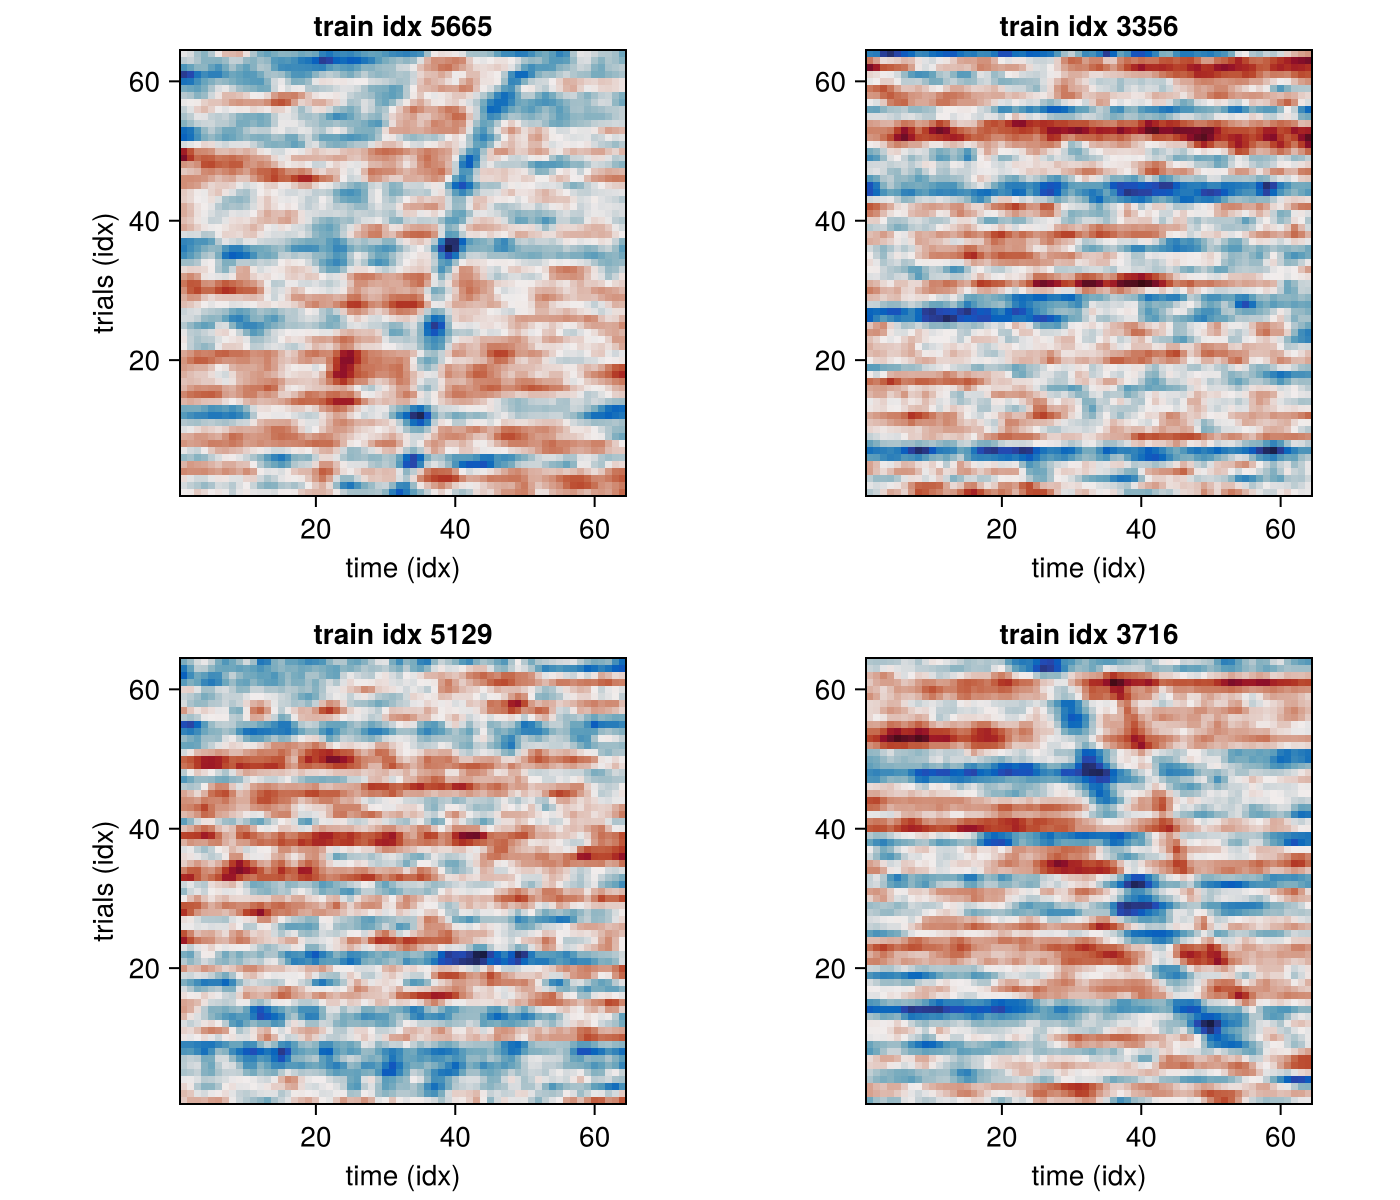

In [6]:
using CairoMakie

# Preview 4 random training ERP images (x=time, y=trials)
@assert size(train_X, 3) == 1 "Expected single-channel ERP images."
rng_preview = Random.Xoshiro(time_ns())
sample_idx = rand(rng_preview, 1:size(train_X, 4), 4)

fig = Figure(size = (700, 600), figure_padding = 5)
for (i, idx) in enumerate(sample_idx)
    row = i <= 2 ? 1 : 2
    col = i <= 2 ? i : i - 2
    img = train_X[:, :, 1, idx]
    vmax = maximum(abs, img)
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)
    ax = Axis(fig[row, col]; title = "train idx " * string(idx), xlabel = "time (idx)", ylabel = (col == 1 ? "trials (idx)" : ""), aspect = AxisAspect(1))
    x = 1:size(img, 2)
    y = 1:size(img, 1)
    heatmap!(ax, x, y, permutedims(img, (2, 1)); colormap = :balance, colorrange = cr)
end
fig


In [7]:
batchsize = 64

train_loader = DataLoader((train_X, train_Y);
    batchsize=batchsize,
    shuffle=true,
)

test_loader = DataLoader((test_X, test_Y);
    batchsize=batchsize,
    shuffle=false,
)

32-element DataLoader(::Tuple{Array{Float32, 4}, Matrix{Float32}}, batchsize=64)
  with first element:
  (64×64×1×64 Array{Float32, 4}, 2×64 Matrix{Float32},)

In [8]:
H, W, C, _ = size(train_X)
n_classes = size(train_Y, 1)

@assert n_classes == 2 "Binary setup expects 2 classes but got $(n_classes)."
@assert H == 64 && W == 64 "CNN expects 64x64 inputs but got $(H)x$(W)."

block1 = Chain(
    Conv((3, 3), C => 16, pad=1), relu,
    MaxPool((2, 2)),
)

block2 = Chain(
    Conv((3, 3), 16 => 32, pad=1), relu,
    MaxPool((2, 2)),
)

block3 = Chain(
    Conv((3, 3), 32 => 64, pad=1), relu,
    MaxPool((2, 2)),
)

head = Chain(
    Flux.flatten,
    Dense(8 * 8 * 64 => 128, relu),
    Dense(128 => n_classes),
    softmax,
)

model_3layer = Chain(block1, block2, block3, head)
model_3layer = device(model_3layer)

block1_simple = Chain(
    Conv((3, 3), C => 16, pad=1),
    relu,
    MaxPool((2, 2)),
)

head_simple = Chain(
    Flux.AdaptiveMeanPool((1, 1)),
    Flux.flatten,
    Dense(16 => n_classes),
    softmax,
)

model_1layer = Chain(block1_simple, head_simple)
model_1layer = device(model_1layer)

# Keep compatibility with downstream analysis cells.
model = model_3layer

println("Model (3-layer) on: ", device_name)
println("Model (1-layer) on: ", device_name)
println("First conv weight type (3-layer): ", typeof(model_3layer[1][1].weight))
println("First conv weight type (1-layer): ", typeof(model_1layer[1][1].weight))


Model (3-layer) on: GPU (CUDA)
Model (1-layer) on: GPU (CUDA)
First conv weight type (3-layer): CuArray{Float32, 4, CUDA.DeviceMemory}
First conv weight type (1-layer): CuArray{Float32, 4, CUDA.DeviceMemory}


In [9]:
loss(m, x, y) = Flux.Losses.crossentropy(m(x), y)

# Compute accuracy for model outputs.
function accuracy(m, x, y; class_range=0:n_classes-1)
    yhat = m(x)
    pred = onecold(cpu(yhat), class_range)
    truth = onecold(cpu(y), class_range)
    return mean(pred .== truth)
end


accuracy (generic function with 1 method)

In [10]:
function train_model!(model, train_loader; nepochs=10, lr=1f-3, name="model")
    optim = Flux.Adam(lr)
    opt_state = Flux.setup(optim, model)

    train_time = @elapsed begin
        for epoch in 1:nepochs
            epoch_loss = 0f0
            nbatch = 0

            for (xb_cpu, yb_cpu) in train_loader
                xb = device(xb_cpu)
                yb = device(yb_cpu)

                loss_val, grads = Flux.withgradient(model) do m
                    loss(m, xb, yb)
                end

                opt_state, model = Flux.update!(opt_state, model, grads[1])
                epoch_loss += loss_val
                nbatch += 1
            end

            @info "$(name) | epoch $epoch: train loss = $(epoch_loss / max(1, nbatch))"
        end
    end

    return model, train_time
end

nepochs = 10
@info "Training for $nepochs epochs on $device_name"

model_3layer, train_time_3layer = train_model!(model_3layer, train_loader;
    nepochs=nepochs,
    lr=1f-3,
    name="3-layer CNN",
)

model_1layer, train_time_1layer = train_model!(model_1layer, train_loader;
    nepochs=nepochs,
    lr=1f-3,
    name="1-layer CNN",
)

# Keep compatibility with downstream analysis cells.
model = model_3layer


┌ Info: Training for 10 epochs on GPU (CUDA)
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:31
┌ Info: 3-layer CNN | epoch 1: train loss = 0.33787107
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:23
┌ Info: 3-layer CNN | epoch 2: train loss = 0.0857192
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:23
┌ Info: 3-layer CNN | epoch 3: train loss = 0.060007
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:23
┌ Info: 3-layer CNN | epoch 4: train loss = 0.05868164
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:23
┌ Info: 3-layer CNN | epoch 5: train loss = 0.051937275
└ @ Main /home/benjamin/Dokumente/BA2

Chain(
  Chain(
    Conv((3, 3), 1 => 16, pad=1),       # 160 parameters
    NNlib.relu,
    MaxPool((2, 2)),
  ),
  Chain(
    Conv((3, 3), 16 => 32, pad=1),      # 4_640 parameters
    NNlib.relu,
    MaxPool((2, 2)),
  ),
  Chain(
    Conv((3, 3), 32 => 64, pad=1),      # 18_496 parameters
    NNlib.relu,
    MaxPool((2, 2)),
  ),
  Chain(
    Flux.flatten,
    Dense(4096 => 128, relu),           # 524_416 parameters
    Dense(128 => 2),                    # 258 parameters
    NNlib.softmax,
  ),
)                   # Total: 10 arrays, 547_970 parameters, 2.008 KiB.

In [11]:
CUDA.reclaim()

function evaluate_model(model, test_loader, test_X)
    y_true_all = Int[]
    y_pred_all = Int[]

    test_scores = Matrix{Float32}(undef, n_classes, size(test_X, 4))
    offset = 0

    val_time = @elapsed begin
        for (xb_cpu, yb_cpu) in test_loader
            xb = device(xb_cpu)
            yhat = cpu(model(xb))

            n = size(yhat, 2)
            test_scores[:, offset+1:offset+n] = yhat
            offset += n

            append!(y_pred_all, onecold(yhat, 0:n_classes-1))
            append!(y_true_all, onecold(yb_cpu, 0:n_classes-1))
        end
    end

    return (
        scores = test_scores,
        y_pred = collect(y_pred_all),
        y_true = collect(y_true_all),
        val_time = val_time,
    )
end

eval_3layer = evaluate_model(model_3layer, test_loader, test_X)
eval_1layer = evaluate_model(model_1layer, test_loader, test_X)

test_scores_3layer = eval_3layer.scores
test_scores_1layer = eval_1layer.scores
y_pred_3layer = eval_3layer.y_pred
y_true_3layer = eval_3layer.y_true
y_pred_1layer = eval_1layer.y_pred
y_true_1layer = eval_1layer.y_true
val_time_3layer = eval_3layer.val_time
val_time_1layer = eval_1layer.val_time

@assert y_true_3layer == y_true_1layer "Ground-truth mismatch between evaluation runs."

# Keep compatibility with downstream analysis cells.
y_true = y_true_3layer
y_pred = y_pred_3layer
test_scores = test_scores_3layer
model = model_3layer

println("Test samples: ", length(y_true_3layer))
println("Example preds (3-layer): ", y_true_3layer[1:min(10, end)], " vs ", y_pred_3layer[1:min(10, end)])
println("Example preds (1-layer): ", y_true_1layer[1:min(10, end)], " vs ", y_pred_1layer[1:min(10, end)])


Test samples: 2000
Example preds (3-layer): [1, 1, 1, 1, 1, 1, 1, 1, 0, 0] vs [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Example preds (1-layer): [1, 1, 1, 1, 1, 1, 1, 1, 0, 0] vs [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]


In [12]:
function compute_metrics(y_pred, y_true)
    acc_m = StatisticalMeasures.Accuracy()
    mcr_m = StatisticalMeasures.MisclassificationRate()
    bacc_m = StatisticalMeasures.BalancedAccuracy()
    macroF1_m = StatisticalMeasures.MulticlassFScore(; average=macro_avg)
    microF1_m = StatisticalMeasures.MulticlassFScore(; average=micro_avg)
    prec_m = StatisticalMeasures.MulticlassPositivePredictiveValue()
    rec_m = StatisticalMeasures.MulticlassTruePositiveRate()
    kap_m = StatisticalMeasures.Kappa()
    cm_m = StatisticalMeasures.ConfusionMatrix()

    cm = cm_m(y_pred, y_true)

    return (
        acc = acc_m(y_pred, y_true),
        mcr = mcr_m(y_pred, y_true),
        bacc = bacc_m(y_pred, y_true),
        macroF1 = macroF1_m(y_pred, y_true),
        microF1 = microF1_m(y_pred, y_true),
        prec = prec_m(y_pred, y_true),
        rec = rec_m(y_pred, y_true),
        kap = kap_m(y_pred, y_true),
        cm = cm,
        cm_mat = CM.matrix(cm),
        cls_lbls = CM.levels(cm),
    )
end

function print_metrics(name, metrics)
    println("\n=== ", name, " | Test Metrics ===")
    @printf("Accuracy               : %.4f\n", metrics.acc)
    @printf("MisclassificationRate  : %.4f\n", metrics.mcr)
    @printf("Balanced Accuracy      : %.4f\n", metrics.bacc)
    @printf("Macro Precision        : %.4f\n", metrics.prec)
    @printf("Macro Recall           : %.4f\n", metrics.rec)
    @printf("Macro F1               : %.4f\n", metrics.macroF1)
    @printf("Micro F1               : %.4f\n", metrics.microF1)
    @printf("Cohen's kappa          : %.4f\n", metrics.kap)

    println("\nConfusion matrix (rows = pred, cols = true):")
    @printf("%-22s", "pred \\ true")
    for lbl in metrics.cls_lbls
        @printf("%6d", Int(lbl))
    end
    println()

    K = length(metrics.cls_lbls)
    for (i, lbl_pred) in enumerate(metrics.cls_lbls)
        class_idx = Int(lbl_pred) + 1
        name_pred = class_idx in eachindex(pattern_names) ? String(pattern_names[class_idx]) : string(lbl_pred)
        @printf("(%d) %-16s", Int(lbl_pred), name_pred[1:min(end, 16)])
        for j in 1:K
            @printf("%6d", metrics.cm_mat[i, j])
        end
        println()
    end
end

metrics_3layer = compute_metrics(y_pred_3layer, y_true_3layer)
metrics_1layer = compute_metrics(y_pred_1layer, y_true_1layer)

acc_3layer = metrics_3layer.acc
mcr_3layer = metrics_3layer.mcr
bacc_3layer = metrics_3layer.bacc
prec_3layer = metrics_3layer.prec
rec_3layer = metrics_3layer.rec
f1_3layer = metrics_3layer.macroF1
microf1_3layer = metrics_3layer.microF1
kap_3layer = metrics_3layer.kap
cm_3layer = metrics_3layer.cm

acc_1layer = metrics_1layer.acc
mcr_1layer = metrics_1layer.mcr
bacc_1layer = metrics_1layer.bacc
prec_1layer = metrics_1layer.prec
rec_1layer = metrics_1layer.rec
f1_1layer = metrics_1layer.macroF1
microf1_1layer = metrics_1layer.microF1
kap_1layer = metrics_1layer.kap
cm_1layer = metrics_1layer.cm

# Backward-compatible aliases for downstream cells.
acc = acc_3layer
mcr = mcr_3layer
bacc = bacc_3layer
macroF1 = f1_3layer
microF1 = microf1_3layer
prec = prec_3layer
rec = rec_3layer
kap = kap_3layer
cm = cm_3layer

print_metrics("3-Layer CNN", metrics_3layer)
print_metrics("1-Layer CNN", metrics_1layer)


┌ Warning: Levels not explicitly ordered. Using the order [0, 1]. The "positive" level is 1. 
└ @ StatisticalMeasures.ConfusionMatrices /home/benjamin/.julia/packages/StatisticalMeasures/RRiuf/src/confusion_matrices.jl:346
┌ Warning: Levels not explicitly ordered. Using the order [0, 1]. The "positive" level is 1. 
└ @ StatisticalMeasures.ConfusionMatrices /home/benjamin/.julia/packages/StatisticalMeasures/RRiuf/src/confusion_matrices.jl:346



=== 3-Layer CNN | Test Metrics ===
Accuracy               : 0.9910
MisclassificationRate  : 0.0090
Balanced Accuracy      : 0.9909
Macro Precision        : 0.9911
Macro Recall           : 0.9909
Macro F1               : 0.9910
Micro F1               : 0.9910
Cohen's kappa          : 0.9820

Confusion matrix (rows = pred, cols = true):
pred \ true                0     1
(0) no_pattern        1012    14
(1) pattern              4   970

=== 1-Layer CNN | Test Metrics ===
Accuracy               : 0.7290
MisclassificationRate  : 0.2710
Balanced Accuracy      : 0.7314
Macro Precision        : 0.7536
Macro Recall           : 0.7314
Macro F1               : 0.7236
Micro F1               : 0.7290
Cohen's kappa          : 0.4606

Confusion matrix (rows = pred, cols = true):
pred \ true                0     1
(0) no_pattern         589   115
(1) pattern            427   869


In [13]:
function count_params(m)
    return sum(length, Flux.params(m))
end

params_3layer = count_params(model_3layer)
params_1layer = count_params(model_1layer)

println(repeat("=", 70))
println("MODEL COMPARISON SUMMARY")
println(repeat("=", 70))
println()
println("Task: Binary Classification (pattern vs. no_pattern)")
println()
println(repeat("-", 70))
println("TIMING")
println(repeat("-", 70))
@printf("%-25s %15s %15s\n", "Metric", "3-Layer CNN", "1-Layer CNN")
@printf("%-25s %15.2fs %15.2fs\n", "Training Time", train_time_3layer, train_time_1layer)
@printf("%-25s %15.2fs %15.2fs\n", "Validation Time", val_time_3layer, val_time_1layer)
println()
println(repeat("-", 70))
println("PERFORMANCE")
println(repeat("-", 70))
@printf("%-25s %15.4f %15.4f\n", "Accuracy", acc_3layer, acc_1layer)
@printf("%-25s %15.4f %15.4f\n", "Balanced Accuracy", bacc_3layer, bacc_1layer)
@printf("%-25s %15.4f %15.4f\n", "Macro F1", f1_3layer, f1_1layer)
println()
println(repeat("-", 70))
println("MODEL SIZE")
println(repeat("-", 70))
@printf("%-25s %15d %15d\n", "Parameters", params_3layer, params_1layer)
println(repeat("=", 70))


┌ Warning: `Flux.params(m...)` is deprecated. Use `Flux.trainable(model)` for parameter collection,
│ and the explicit `gradient(m -> loss(m, x, y), model)` for gradient computation.
└ @ Flux /home/benjamin/.julia/packages/Flux/WMUyh/src/deprecations.jl:93


MODEL COMPARISON SUMMARY

Task: Binary Classification (pattern vs. no_pattern)

----------------------------------------------------------------------
TIMING
----------------------------------------------------------------------
Metric                        3-Layer CNN     1-Layer CNN
Training Time                       35.11s            2.88s
Validation Time                      0.33s            0.08s

----------------------------------------------------------------------
PERFORMANCE
----------------------------------------------------------------------
Accuracy                           0.9910          0.7290
Balanced Accuracy                  0.9909          0.7314
Macro F1                           0.9910          0.7236

----------------------------------------------------------------------
MODEL SIZE
----------------------------------------------------------------------
Parameters                         547970             194


In [14]:
# Sort and format class scores.
function format_scores(scores, names; topk=length(names))
    pairs = collect(zip(names, scores))
    sort!(pairs; by=x -> x[2], rev=true)
    return pairs[1:min(topk, length(pairs))]
end

format_scores (generic function with 1 method)

Sample index: 1943
True label : pattern
Pred label : pattern
Variant   : inverted
Trial order: normal
Inverted  : true
Sampling  : 356
Crop ms   : 15 / 6
Scores:
  pattern => 1.0
  no_pattern => 0.0


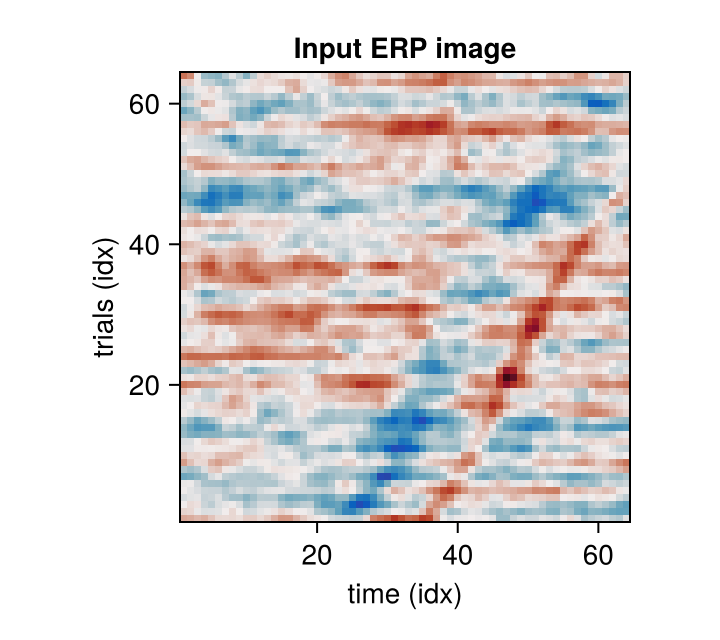

In [22]:
using CairoMakie

sample_idx = rand(1:size(test_X, 4))
sample_img = test_X[:, :, 1, sample_idx]
sample_scores = test_scores[:, sample_idx]

true_lbl = pattern_names[y_true[sample_idx]+1]
pred_lbl = pattern_names[y_pred[sample_idx]+1]
sample_meta = test_meta[sample_idx]

println("Sample index: ", sample_idx)
println("True label : ", true_lbl)
println("Pred label : ", pred_lbl)
if hasproperty(sample_meta, :variant)
    println("Variant   : ", sample_meta.variant)
end
if hasproperty(sample_meta, :trial_order)
    println("Trial order: ", sample_meta.trial_order)
end
if hasproperty(sample_meta, :inverted)
    println("Inverted  : ", sample_meta.inverted)
end
if hasproperty(sample_meta, :sampling_rate)
    println("Sampling  : ", sample_meta.sampling_rate)
end
if hasproperty(sample_meta, :crop_start_ms) && hasproperty(sample_meta, :crop_end_ms)
    println("Crop ms   : ", sample_meta.crop_start_ms, " / ", sample_meta.crop_end_ms)
end
println("Scores:")
for (name, score) in format_scores(sample_scores, pattern_names)
    println("  ", name, " => ", round(score, digits=4))
end

fig = Figure(size=(360, 320))
ax = Axis(fig[1, 1]; title="Input ERP image", xlabel="time (idx)", ylabel="trials (idx)", aspect=AxisAspect(1))
x = 1:size(sample_img, 2)
y = 1:size(sample_img, 1)
vmax = maximum(abs, sample_img)
vmax = vmax == 0 ? 1f-6 : vmax
cr = (-vmax, vmax)
heatmap!(ax, x, y, permutedims(sample_img, (2, 1)); colormap = :balance, colorrange = cr)
fig


Output scores:
  pattern => 1.0
  no_pattern => 0.0


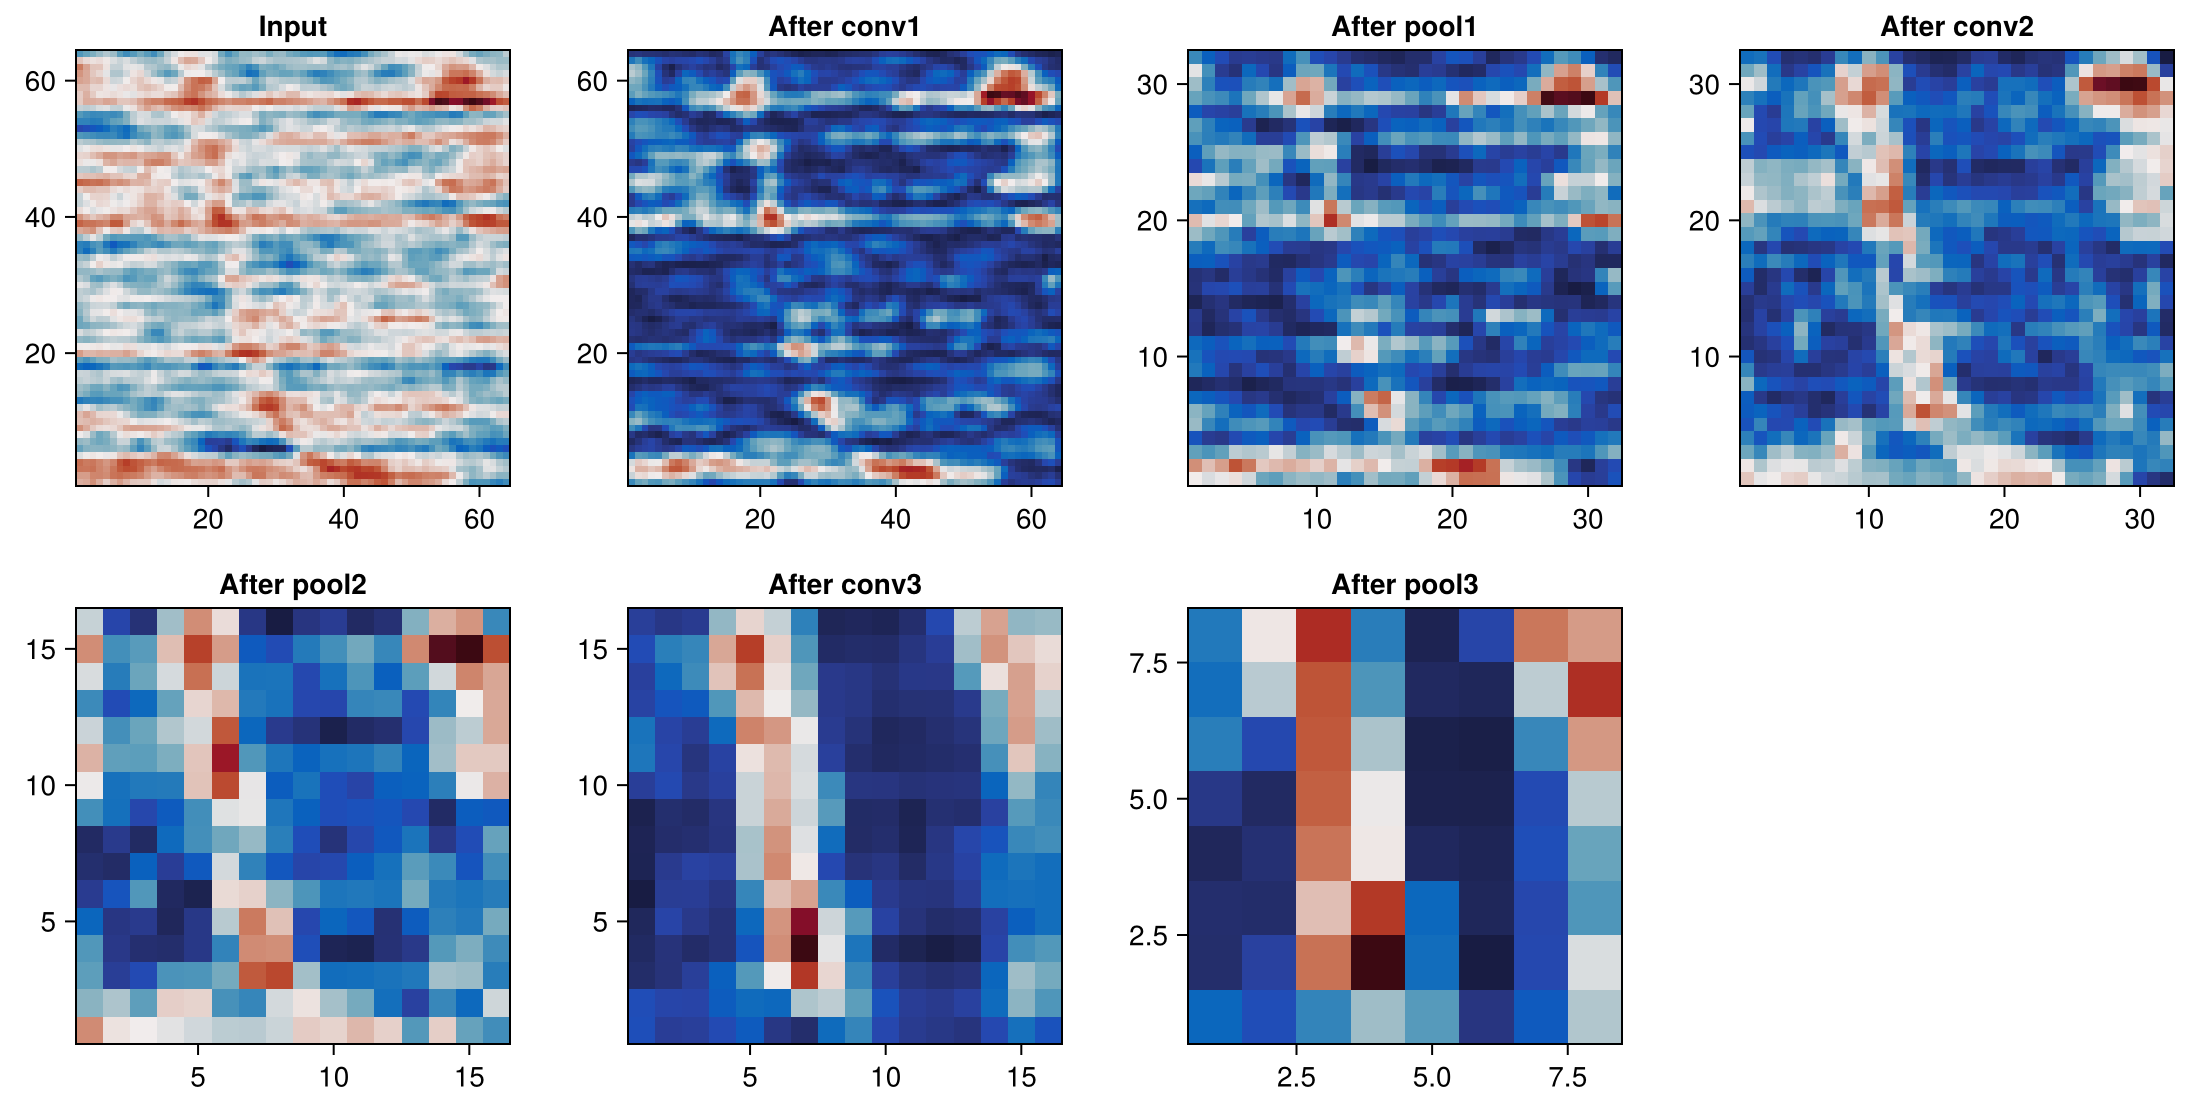

In [23]:
using CairoMakie

sample_idx = rand(1:size(test_X, 4))

x0 = test_X[:, :, :, sample_idx:sample_idx]
x0_dev = device(x0)

block1_dev, block2_dev, block3_dev, head_dev = model[1], model[2], model[3], model[4]
conv1, relu1, pool1 = block1_dev[1], block1_dev[2], block1_dev[3]
conv2, relu2, pool2 = block2_dev[1], block2_dev[2], block2_dev[3]
conv3, relu3, pool3 = block3_dev[1], block3_dev[2], block3_dev[3]

x1c = conv1(x0_dev)
x1 = relu1(x1c)
x1p = pool1(x1)

x2c = conv2(x1p)
x2 = relu2(x2c)
x2p = pool2(x2)

x3c = conv3(x2p)
x3 = relu3(x3c)
x3p = pool3(x3)

scores = cpu(head_dev(x3p))[:, 1]

# Convert a feature tensor to a 2D image.
function to_image(x)
    x_cpu = Array(cpu(x))
    if ndims(x_cpu) == 4
        return dropdims(mean(x_cpu; dims=3), dims=3)[:, :, 1]
    elseif ndims(x_cpu) == 3
        return dropdims(mean(x_cpu; dims=3), dims=3)
    else
        return x_cpu
    end
end

imgs = [
    to_image(x0),
    to_image(x1),
    to_image(x1p),
    to_image(x2),
    to_image(x2p),
    to_image(x3),
    to_image(x3p),
]

titles = [
    "Input",
    "After conv1",
    "After pool1",
    "After conv2",
    "After pool2",
    "After conv3",
    "After pool3",
]

fig = Figure(size=(1100, 550), figure_padding=5)
colgap!(fig.layout, 8)
rowgap!(fig.layout, 8)

for (i, img) in enumerate(imgs)
    row = i <= 4 ? 1 : 2
    col = i <= 4 ? i : (i - 4)
    ax = Axis(fig[row, col]; title=titles[i], aspect=AxisAspect(1))
    heatmap!(ax, permutedims(img, (2, 1)); colormap=:balance)
end

println("Output scores:")
for (name, score) in format_scores(scores, pattern_names)
    println("  ", name, " => ", round(score, digits=4))
end

fig

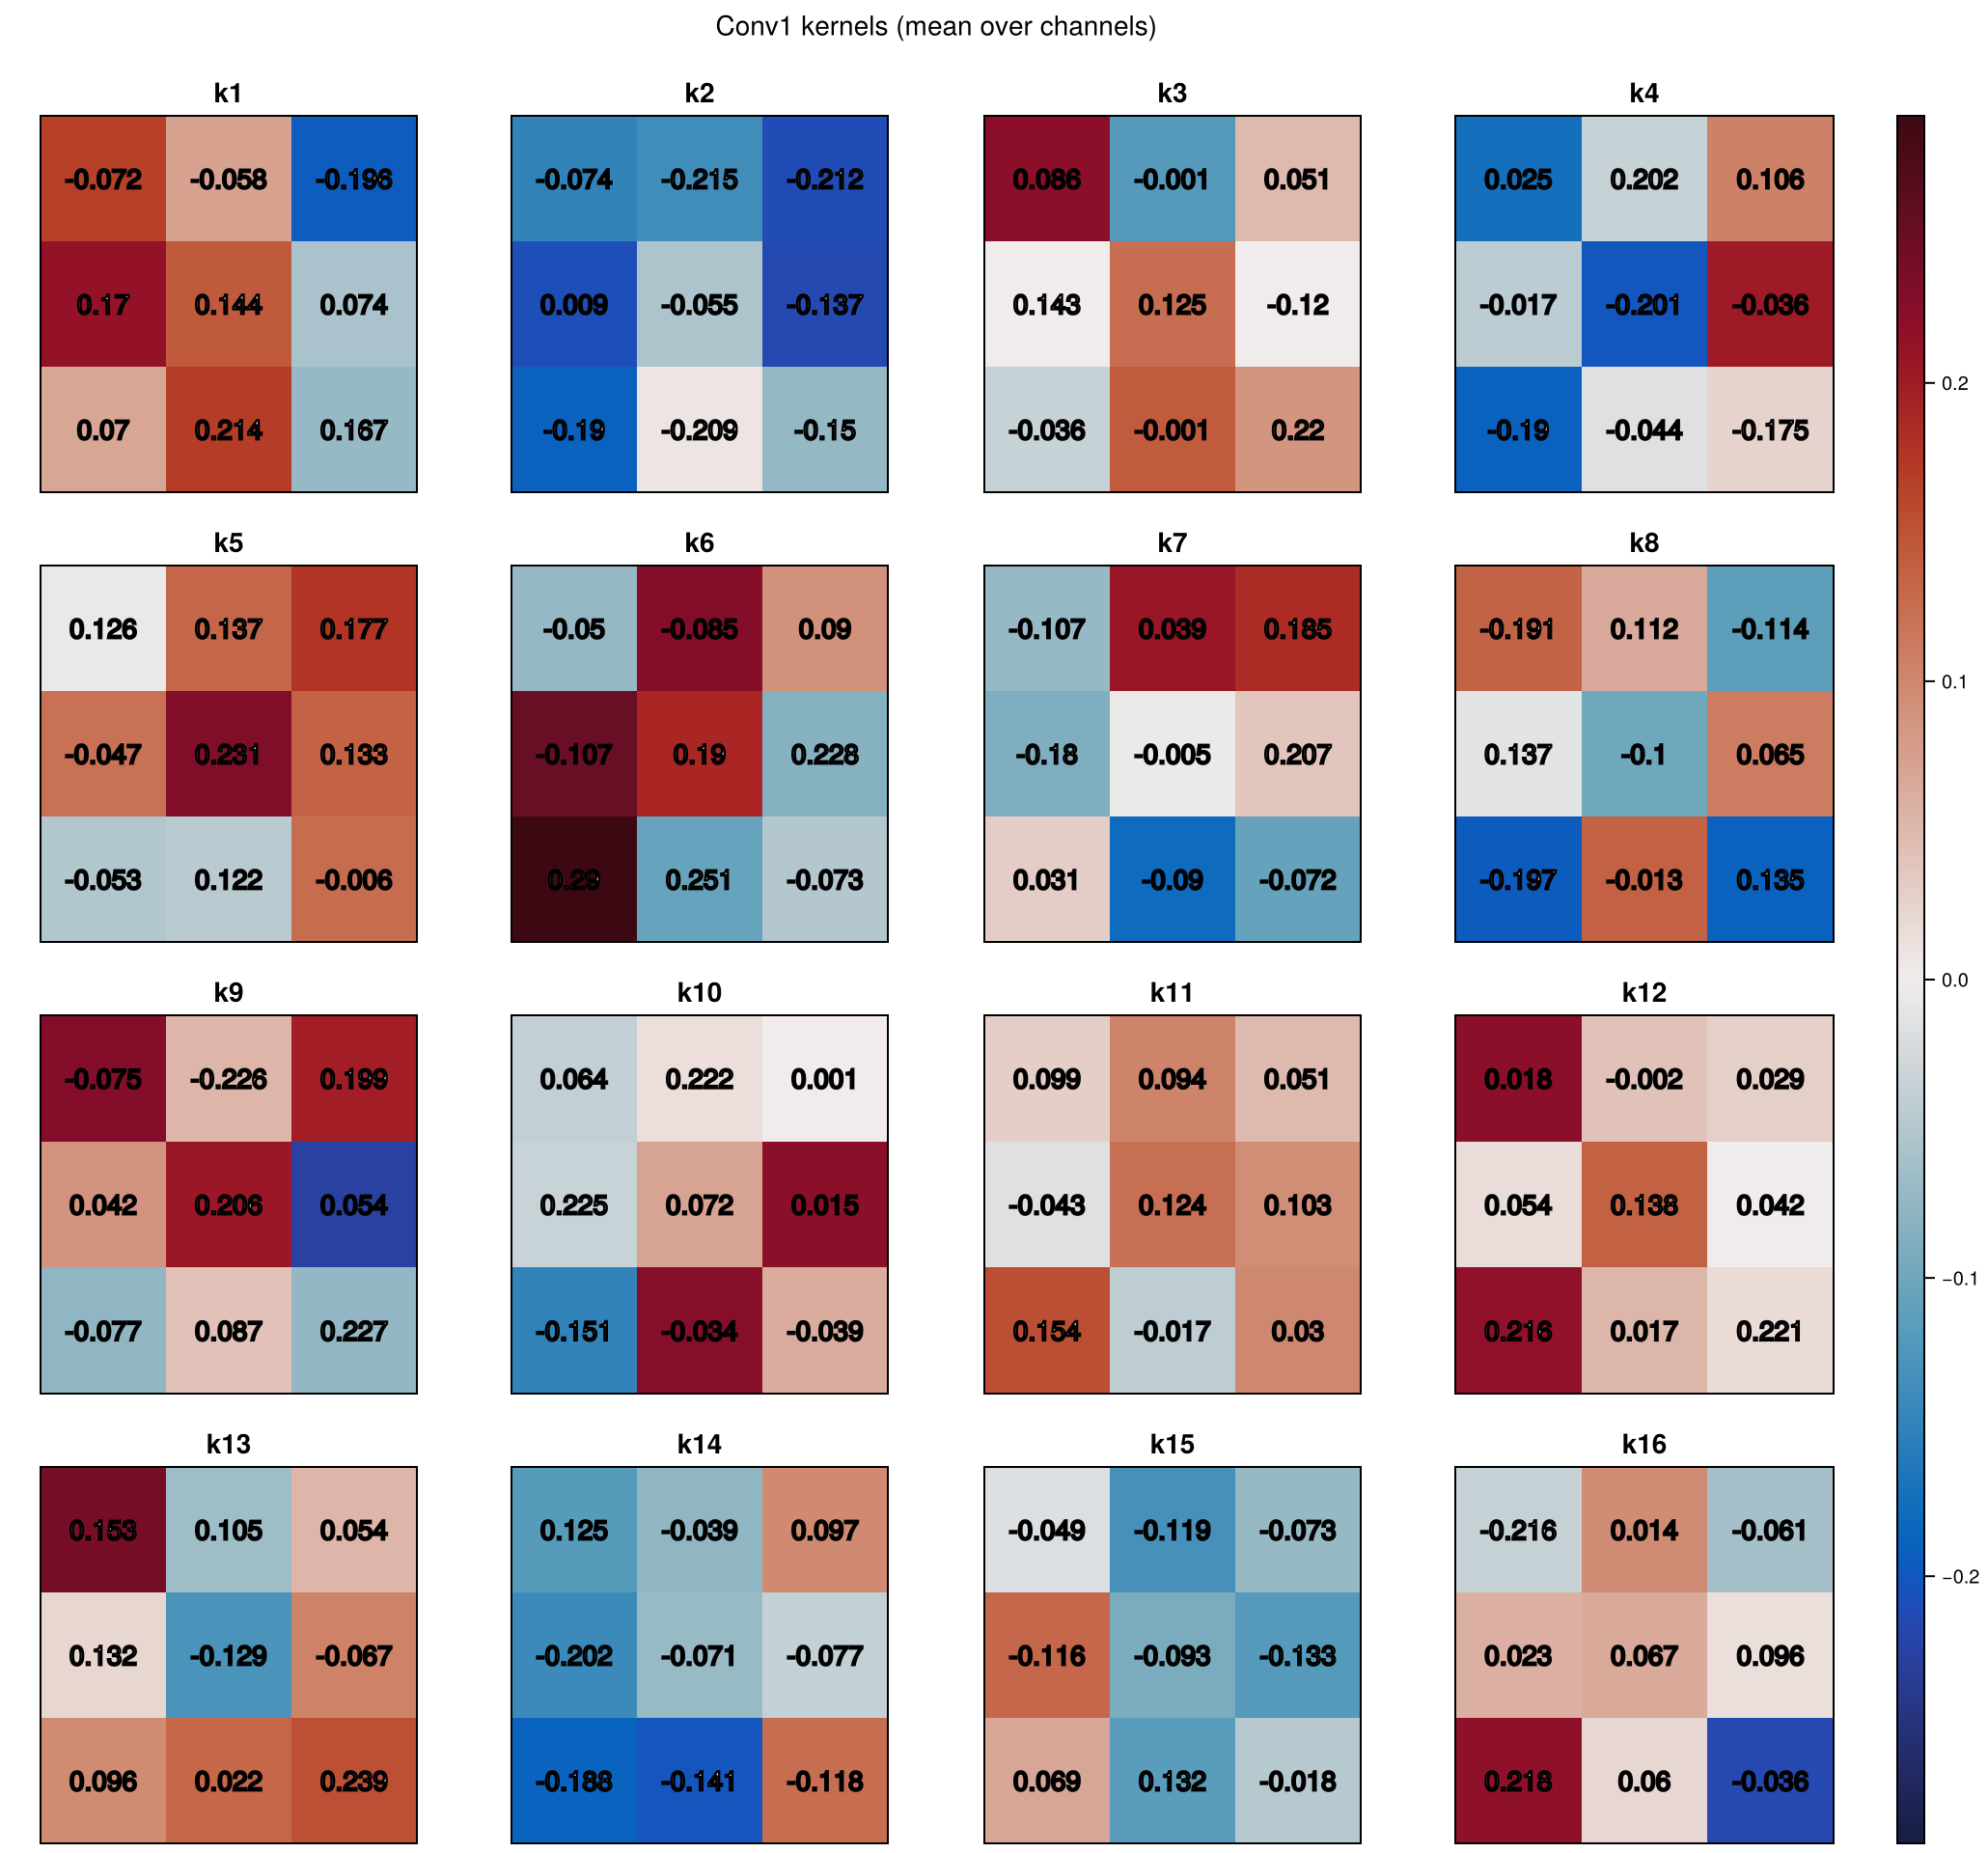

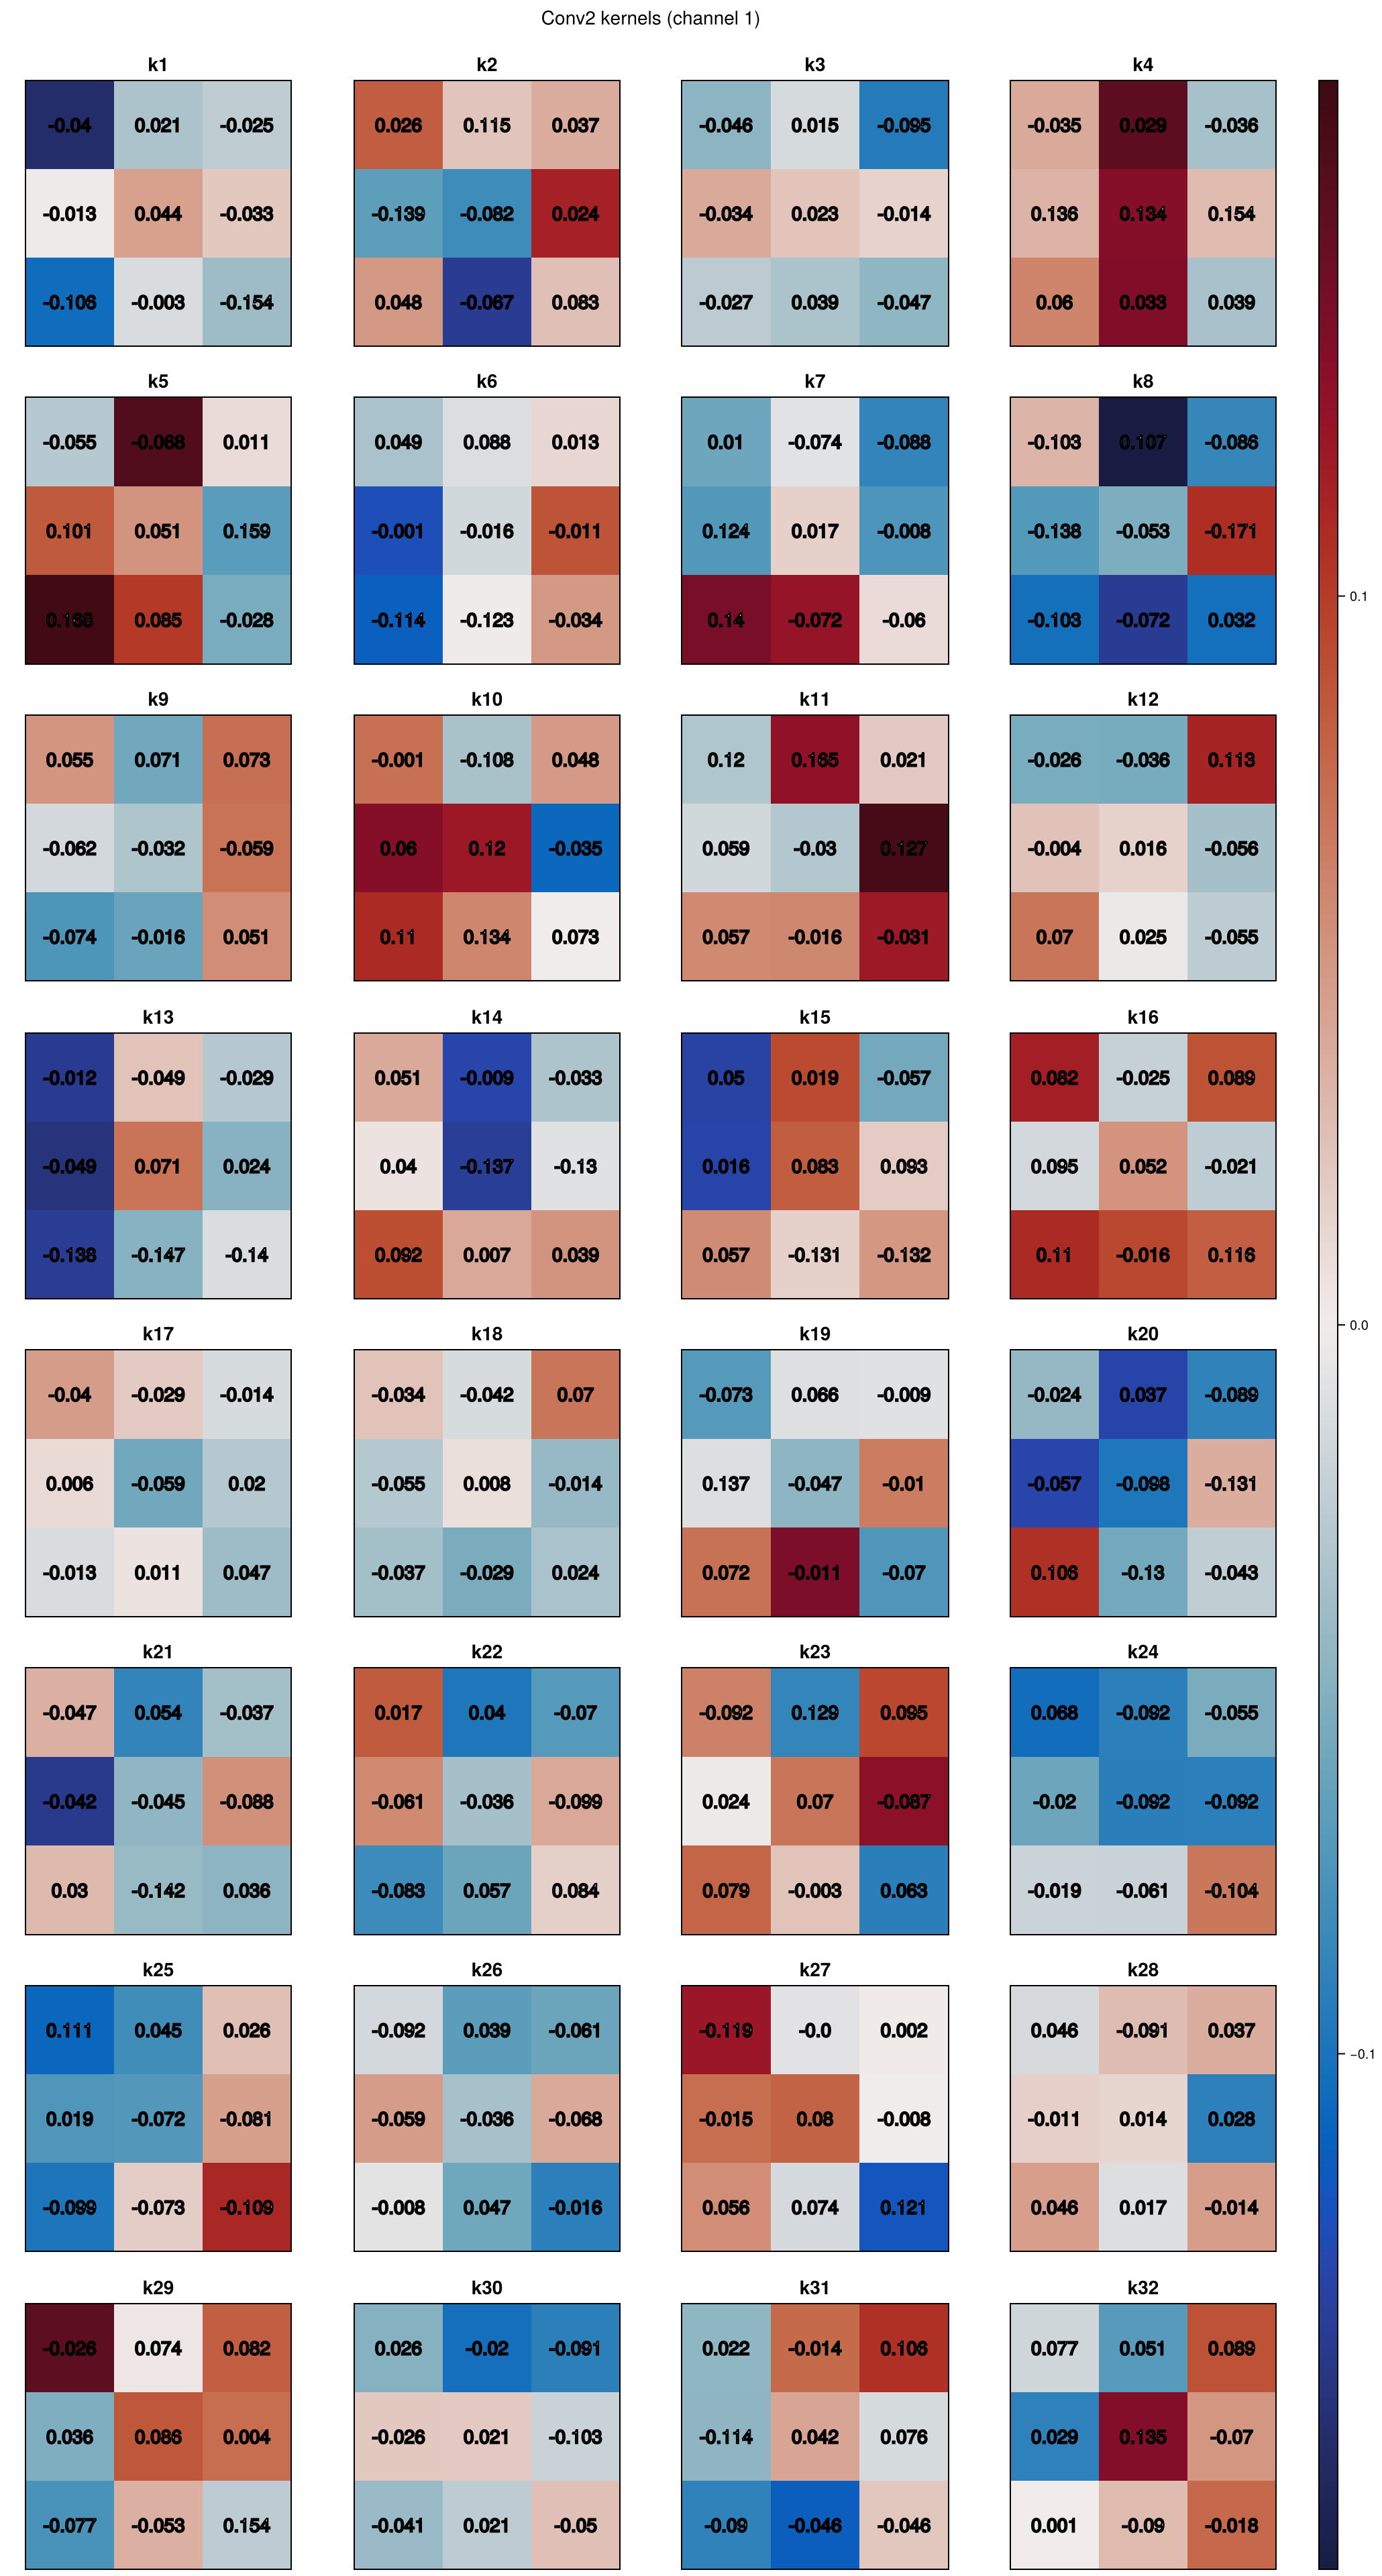

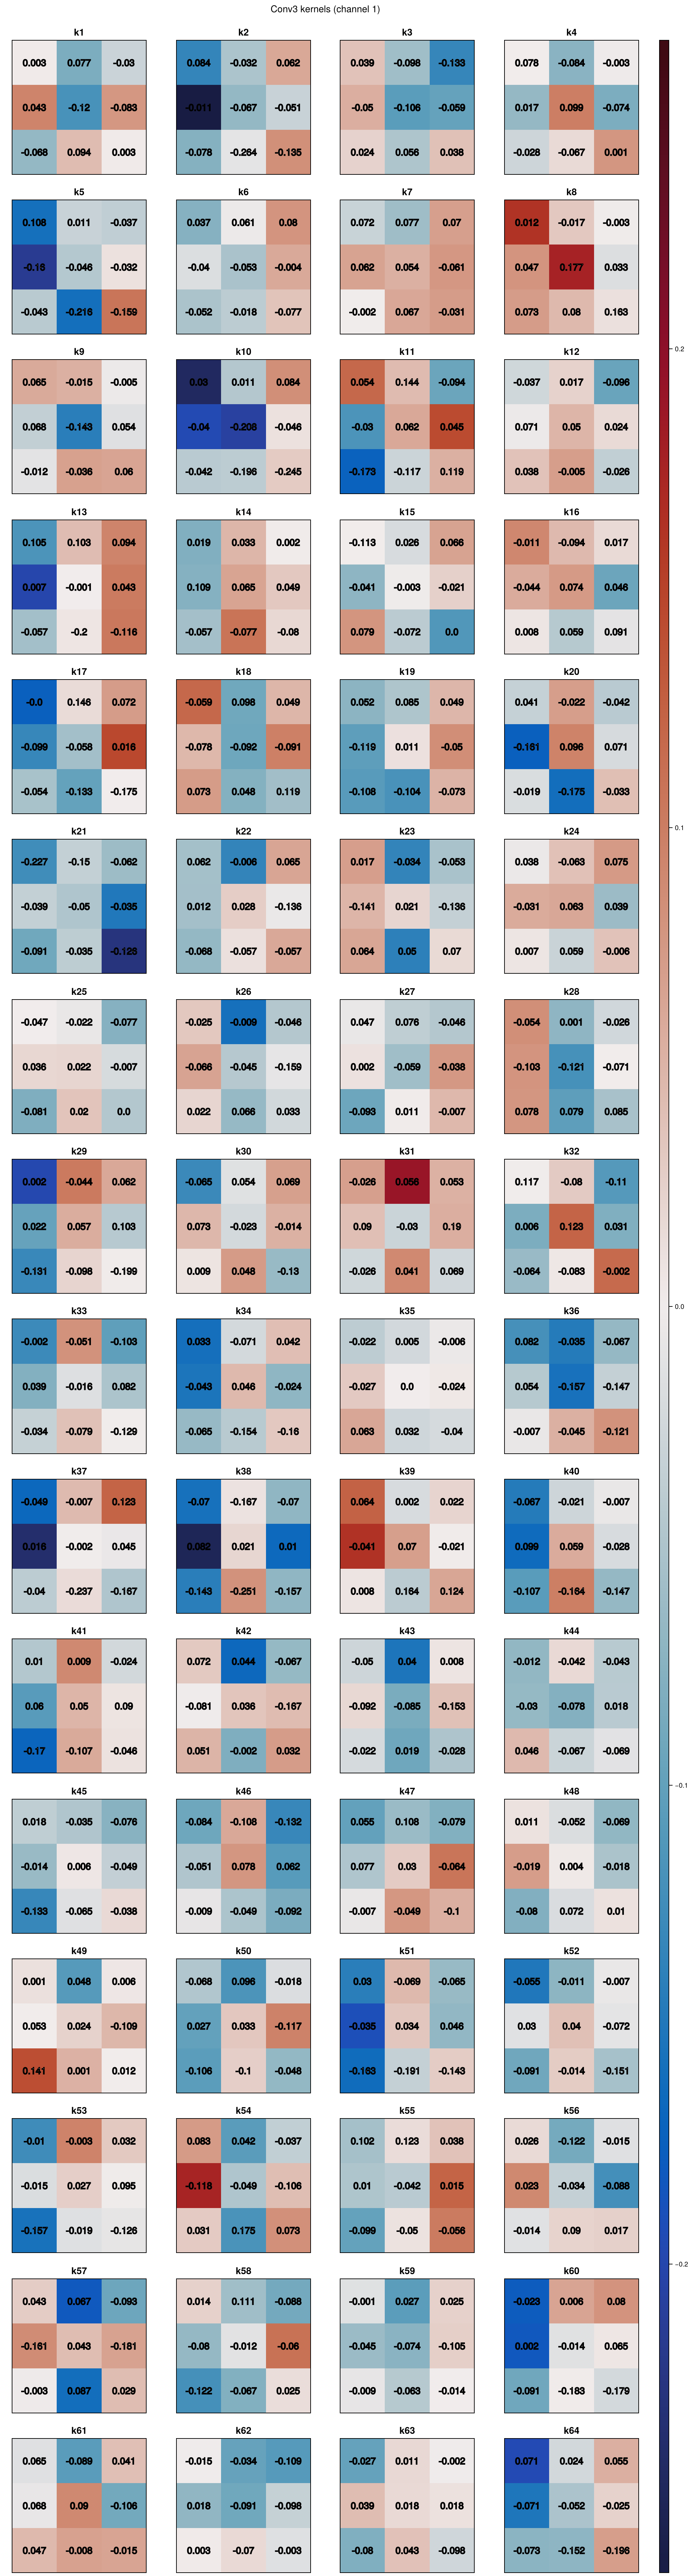


Conv1 kernel values (mean over channels):
Kernel 1:
Float32[0.0697 0.1695 -0.0721; 0.214 0.1436 -0.0579; 0.1672 0.0739 -0.1958]
Kernel 2:
Float32[-0.1899 0.0085 -0.0741; -0.2091 -0.0552 -0.215; -0.1503 -0.1372 -0.2123]
Kernel 3:
Float32[-0.0358 0.1429 0.0862; -0.001 0.1246 -0.0008; 0.22 -0.1196 0.0507]
Kernel 4:
Float32[-0.1897 -0.017 0.0249; -0.0444 -0.2009 0.2021; -0.1752 -0.0356 0.1058]
Kernel 5:
Float32[-0.0529 -0.0466 0.1263; 0.1225 0.2308 0.1367; -0.0058 0.1327 0.177]
Kernel 6:
Float32[0.2895 -0.1069 -0.0504; 0.2509 0.1895 -0.0846; -0.0732 0.2275 0.0905]
Kernel 7:
Float32[0.0314 -0.18 -0.1074; -0.0897 -0.005 0.0392; -0.072 0.2074 0.1847]
Kernel 8:
Float32[-0.1973 0.1369 -0.1906; -0.0132 -0.1003 0.1116; 0.1351 0.0653 -0.1138]
Kernel 9:
Float32[-0.0771 0.0424 -0.0752; 0.0874 0.2061 -0.2263; 0.2274 0.0537 0.1985]
Kernel 10:
Float32[-0.1507 0.2255 0.0635; -0.0344 0.0724 0.2224; -0.0395 0.0146 0.0011]
Kernel 11:
Float32[0.1544 -0.0426 0.0989; -0.0166 0.124 0.0938; 0.0299 0.1032 0.050

In [17]:
using CairoMakie

CairoMakie.activate!()

# Extract kernel images from a convolutional weight tensor.
function kernel_images(w; max_kernels=typemax(Int), channel=:mean)
    w_cpu = Array(cpu(w))
    kh, kw, cin, cout = size(w_cpu)
    nshow = min(max_kernels, cout)
    imgs = Vector{Matrix{Float32}}(undef, nshow)
    for i in 1:nshow
        k = w_cpu[:, :, :, i]
        if channel === :mean
            imgs[i] = dropdims(mean(k; dims=3), dims=3)
        else
            ch = clamp(Int(channel), 1, cin)
            imgs[i] = k[:, :, ch]
        end
    end
    return imgs
end

# Add numeric annotations to a heatmap.
function annotate_heatmap!(ax, mat, vmax; digits=3)
    rows, cols = size(mat)
    for r in 1:rows
        for c in 1:cols
            val = round(mat[r, c]; digits=digits)
            fg = abs(val) > 0.45 * vmax ? :white : :black
            text!(ax, c, r;
                text=string(val),
                align=(:center, :center),
                color=fg,
                strokecolor=:black,
                strokewidth=1.2,
                fontsize=14,
            )
        end
    end
end

# Plot convolutional kernels as heatmaps.
function plot_kernels(w; title="", max_kernels=typemax(Int), channel=:mean, digits=3)
    imgs = kernel_images(w; max_kernels=max_kernels, channel=channel)
    nshow = length(imgs)
    ncols = min(4, nshow)
    nrows = cld(nshow, ncols)

    fig = Figure(size=(240 * ncols + 70, 240 * nrows), figure_padding=5)
    colgap!(fig.layout, 8)
    rowgap!(fig.layout, 8)

    vmax = maximum(abs, reduce(hcat, vec.(imgs)))
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)

    hm_ref = nothing

    for (i, img) in enumerate(imgs)
        row = cld(i, ncols)
        col = i - (row - 1) * ncols
        ax = Axis(fig[row, col];
            title="k" * string(i),
            aspect=AxisAspect(1),
            xticksvisible=false,
            yticksvisible=false,
            xticklabelsvisible=false,
            yticklabelsvisible=false,
        )

        show_img = permutedims(img, (2, 1))

        hm = heatmap!(ax, show_img;
            colormap=:balance,
            colorrange=cr,
        )
        annotate_heatmap!(ax, show_img, vmax; digits=digits)
        hm_ref === nothing && (hm_ref = hm)
    end

    if !isempty(title)
        Label(fig[0, 1:ncols], title; tellwidth=false)
    end

    if hm_ref !== nothing
        Colorbar(fig[1:nrows, ncols+1], hm_ref; width=14, ticklabelsize=10)
    end

    return fig
end

# Print kernel values to the console.
function print_kernels(w; max_kernels=typemax(Int), channel=:mean, digits=4)
    w_cpu = Array(cpu(w))
    kh, kw, cin, cout = size(w_cpu)
    nshow = min(max_kernels, cout)
    for i in 1:nshow
        k = w_cpu[:, :, :, i]
        mat = channel === :mean ? dropdims(mean(k; dims=3), dims=3) : k[:, :, clamp(Int(channel), 1, cin)]
        println("Kernel ", i, ":")
        println(round.(mat, digits=digits))
    end
end

conv1 = model[1][1].weight
conv2 = model[2][1].weight
conv3 = model[3][1].weight

fig1 = plot_kernels(conv1; title="Conv1 kernels (mean over channels)", max_kernels=typemax(Int), digits=3)
fig2 = plot_kernels(conv2; title="Conv2 kernels (channel 1)", max_kernels=typemax(Int), channel=1, digits=3)
fig3 = plot_kernels(conv3; title="Conv3 kernels (channel 1)", max_kernels=typemax(Int), channel=1, digits=3)

display(fig1)
display(fig2)
display(fig3)

println("\nConv1 kernel values (mean over channels):")
print_kernels(conv1; max_kernels=typemax(Int), channel=:mean)

println("\nConv2 kernel values (channel 1):")
print_kernels(conv2; max_kernels=typemax(Int), channel=1)

println("\nConv3 kernel values (channel 1):")
print_kernels(conv3; max_kernels=typemax(Int), channel=1)

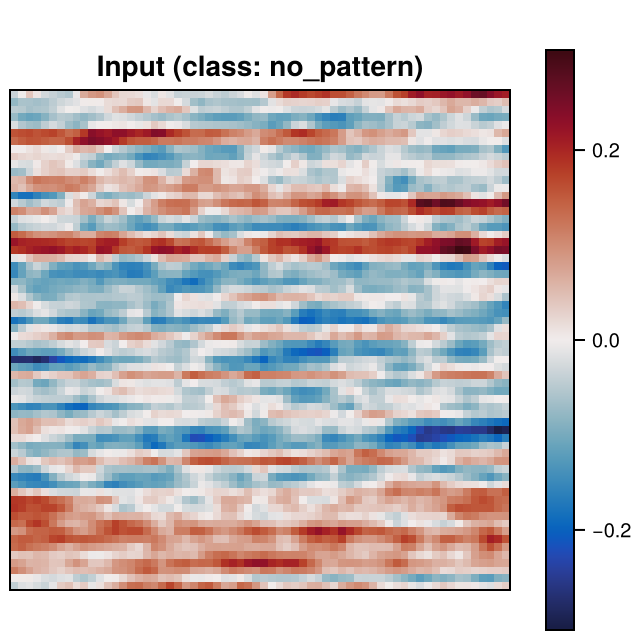

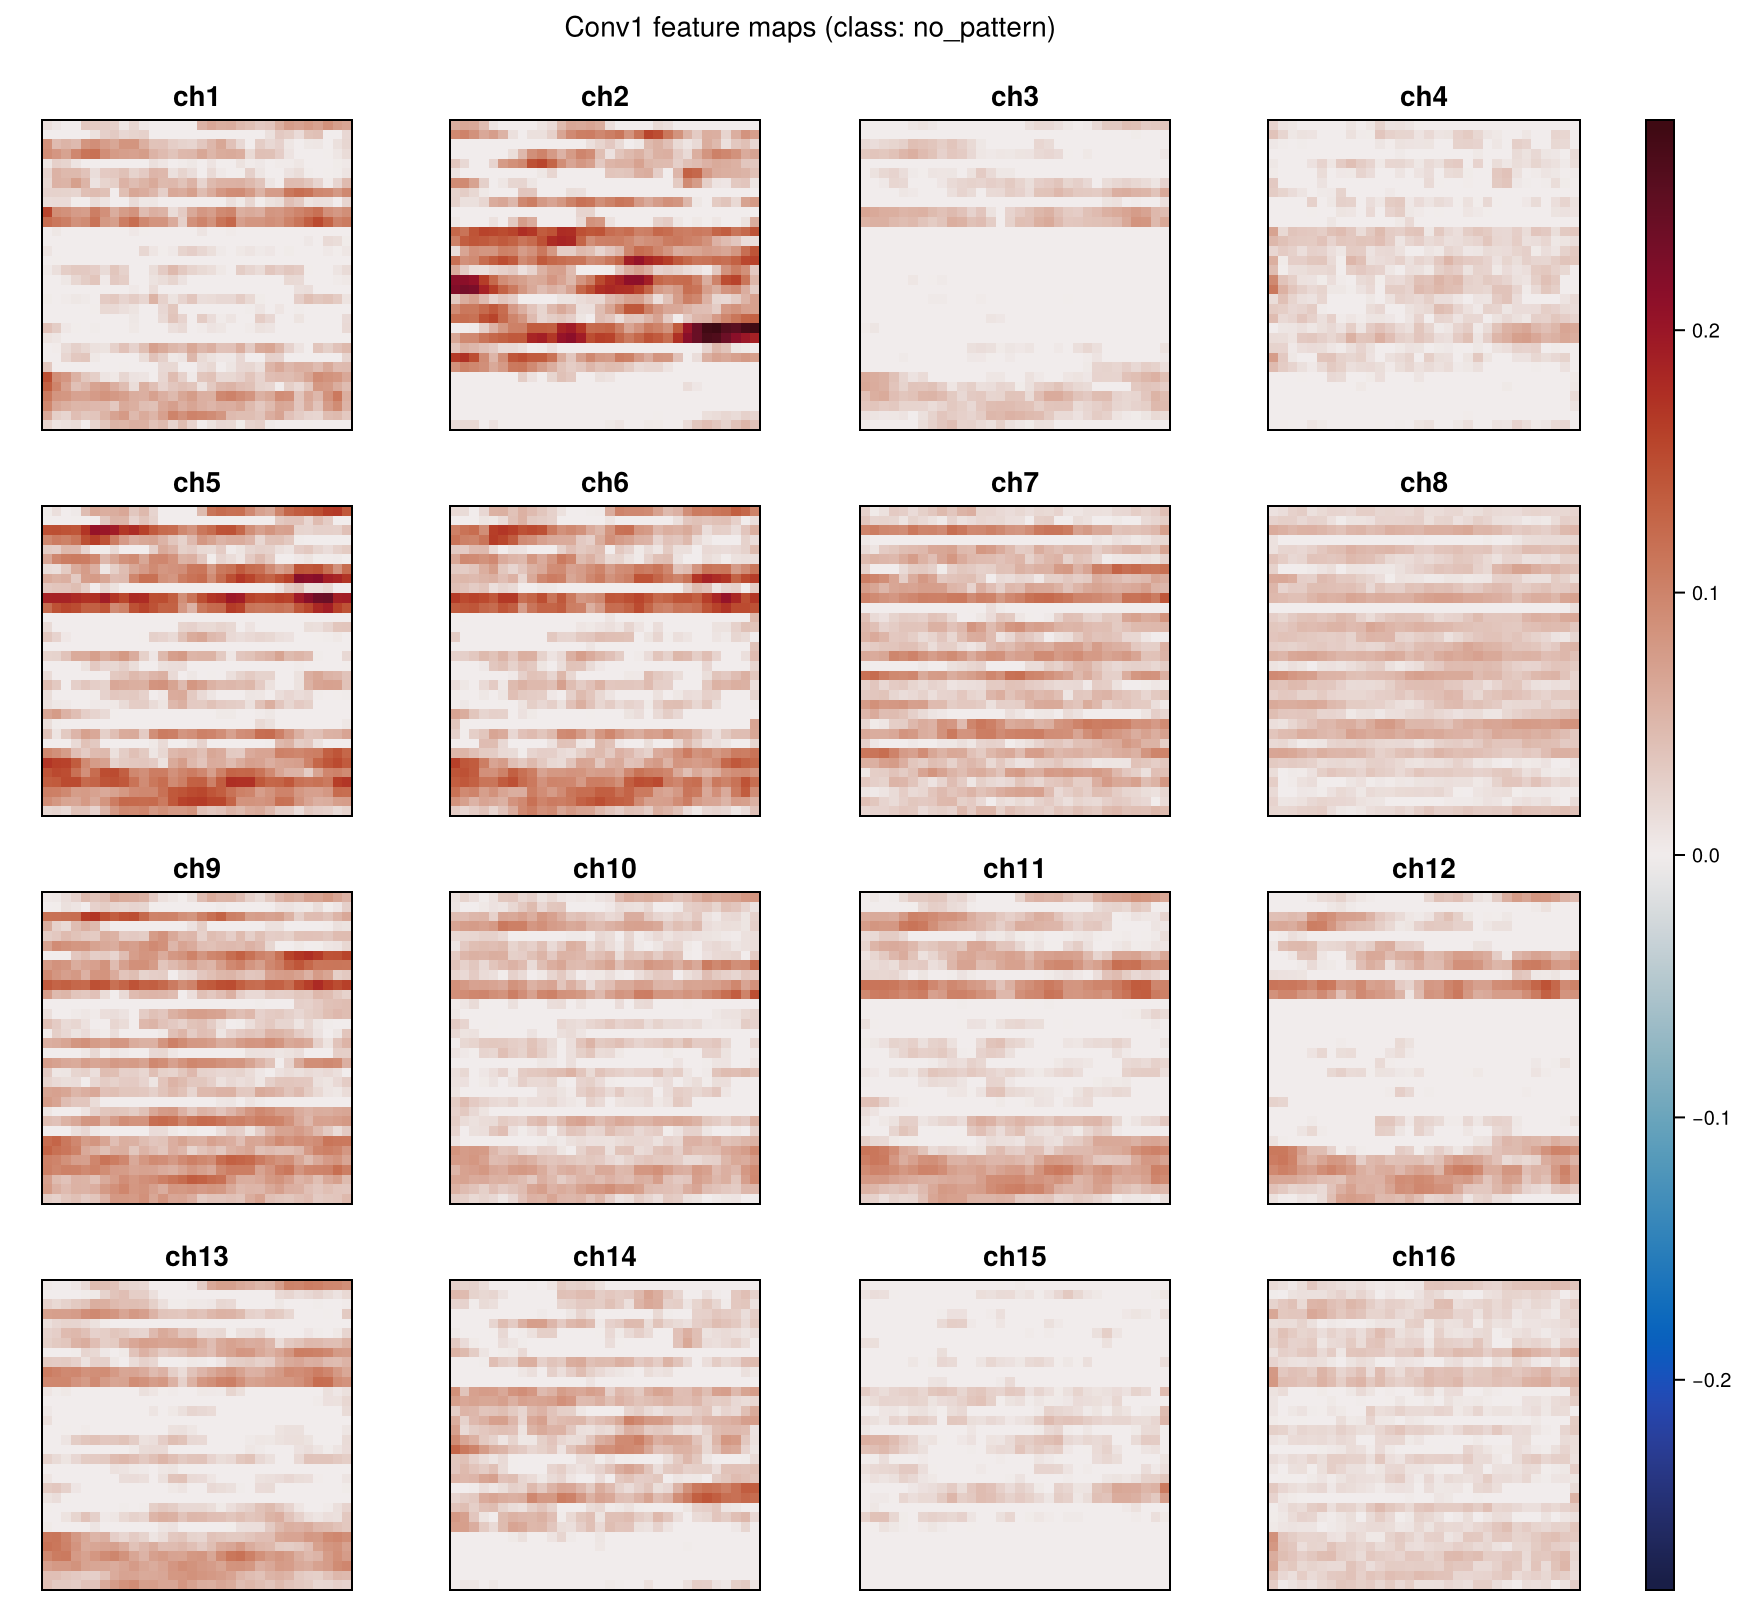

CairoMakie.Screen{IMAGE}


In [18]:
using CairoMakie

CairoMakie.activate!()

# Random test sample (fixed for all feature-map plots below)
sample_idx = rand(1:size(test_X, 4))

x0 = test_X[:, :, :, sample_idx:sample_idx]
x0_dev = device(x0)

block1_dev, block2_dev, block3_dev = model[1], model[2], model[3]

feat1 = Array(cpu(block1_dev(x0_dev)))
feat2 = Array(cpu(block2_dev(block1_dev(x0_dev))))
feat3 = Array(cpu(block3_dev(block2_dev(block1_dev(x0_dev)))))

input_img = Array(cpu(x0))[:, :, 1, 1]

# Resolve class name for a sample index.
function class_name_for(idx)
    if isdefined(Main, :y_true)
        return string(pattern_names[y_true[idx]+1])
    end
    if isdefined(Main, :test_Y)
        lbl = onecold(test_Y[:, idx], 0:length(pattern_names)-1)
        return string(pattern_names[lbl+1])
    end
    return "unknown"
end

class_name = class_name_for(sample_idx)

# Plot an input image with a colorbar.
function plot_input(img; title="Input")
    vmax = maximum(abs, img)
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)

    fig = Figure(size=(320, 320), figure_padding=5)
    ax = Axis(fig[1, 1];
        title=title,
        aspect=AxisAspect(1),
        xticksvisible=false,
        yticksvisible=false,
        xticklabelsvisible=false,
        yticklabelsvisible=false,
    )
    hm = heatmap!(ax, permutedims(img, (2, 1)); colormap=:balance, colorrange=cr)
    Colorbar(fig[1, 2], hm; width=14, ticklabelsize=10)
    return fig
end

# Plot a grid of feature maps.
function plot_feature_grid(feat; title="")
    nshow = size(feat, 3)
    ncols = nshow <= 16 ? 4 : nshow <= 64 ? 8 : 10
    nrows = cld(nshow, ncols)
    tile = nshow <= 16 ? 200 : nshow <= 64 ? 140 : 120

    vmax = maximum(abs, feat)
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)

    fig = Figure(size=(tile * ncols + 70, tile * nrows), figure_padding=5)
    colgap!(fig.layout, 6)
    rowgap!(fig.layout, 6)

    hm_ref = nothing
    for i in 1:nshow
        row = cld(i, ncols)
        col = i - (row - 1) * ncols
        ax = Axis(fig[row, col];
            title="ch" * string(i),
            aspect=AxisAspect(1),
            xticksvisible=false,
            yticksvisible=false,
            xticklabelsvisible=false,
            yticklabelsvisible=false,
        )
        img = feat[:, :, i, 1]
        hm = heatmap!(ax, permutedims(img, (2, 1)); colormap=:balance, colorrange=cr)
        hm_ref === nothing && (hm_ref = hm)
    end

    if !isempty(title)
        Label(fig[0, 1:ncols], title; tellwidth=false)
    end

    if hm_ref !== nothing
        Colorbar(fig[1:nrows, ncols+1], hm_ref; width=14, ticklabelsize=10)
    end

    return fig
end

display(plot_input(input_img; title="Input (class: " * class_name * ")"))
display(plot_feature_grid(feat1; title="Conv1 feature maps (class: " * class_name * ")"))

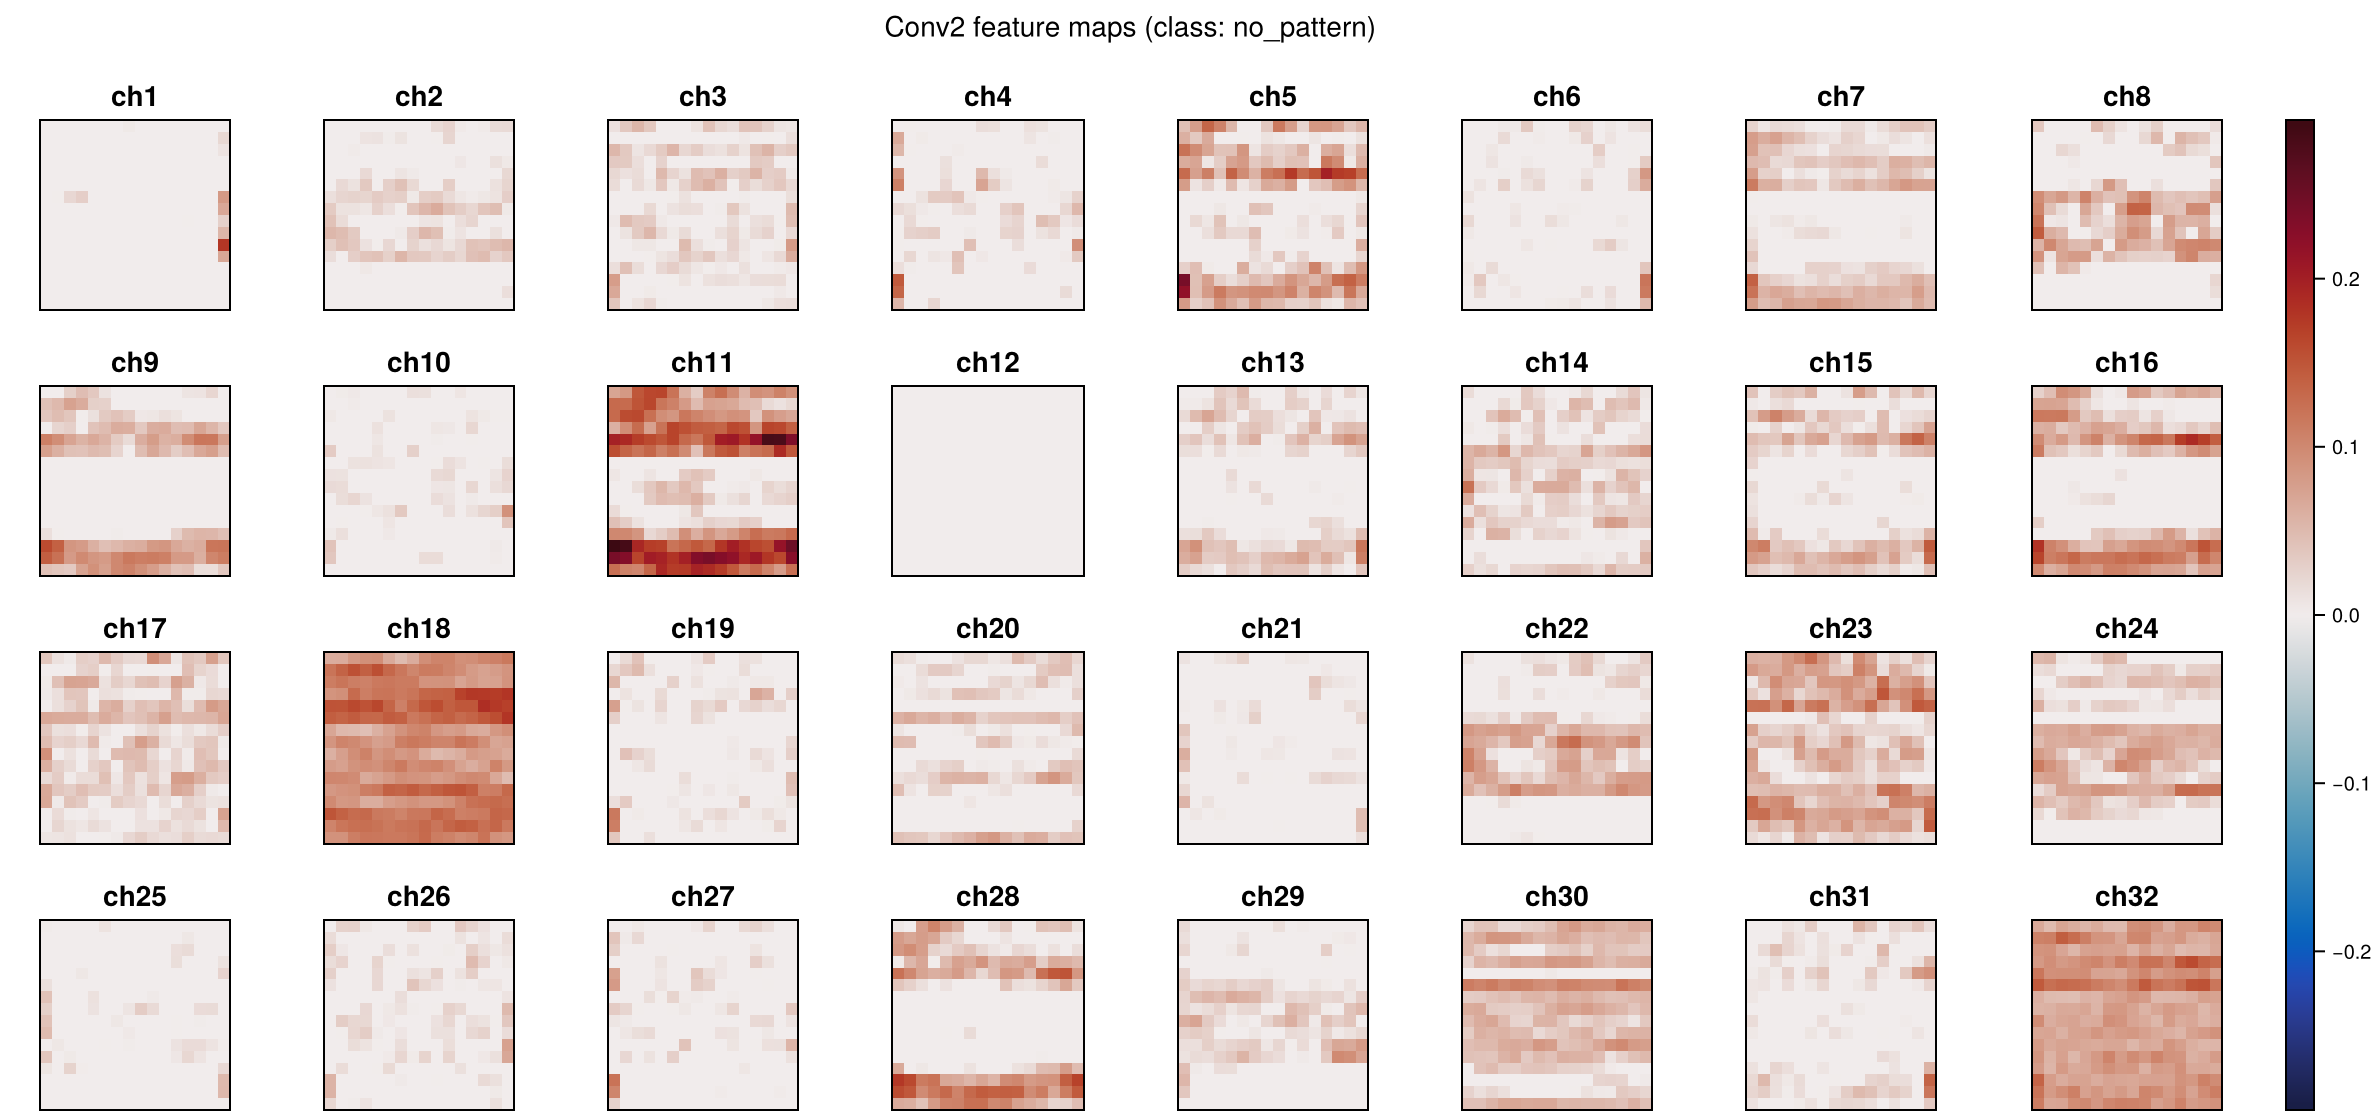

CairoMakie.Screen{IMAGE}


In [19]:
using CairoMakie

# Uses sample_idx, feat2, plot_feature_grid from the previous cell

display(plot_feature_grid(feat2; title="Conv2 feature maps (class: " * class_name * ")"))

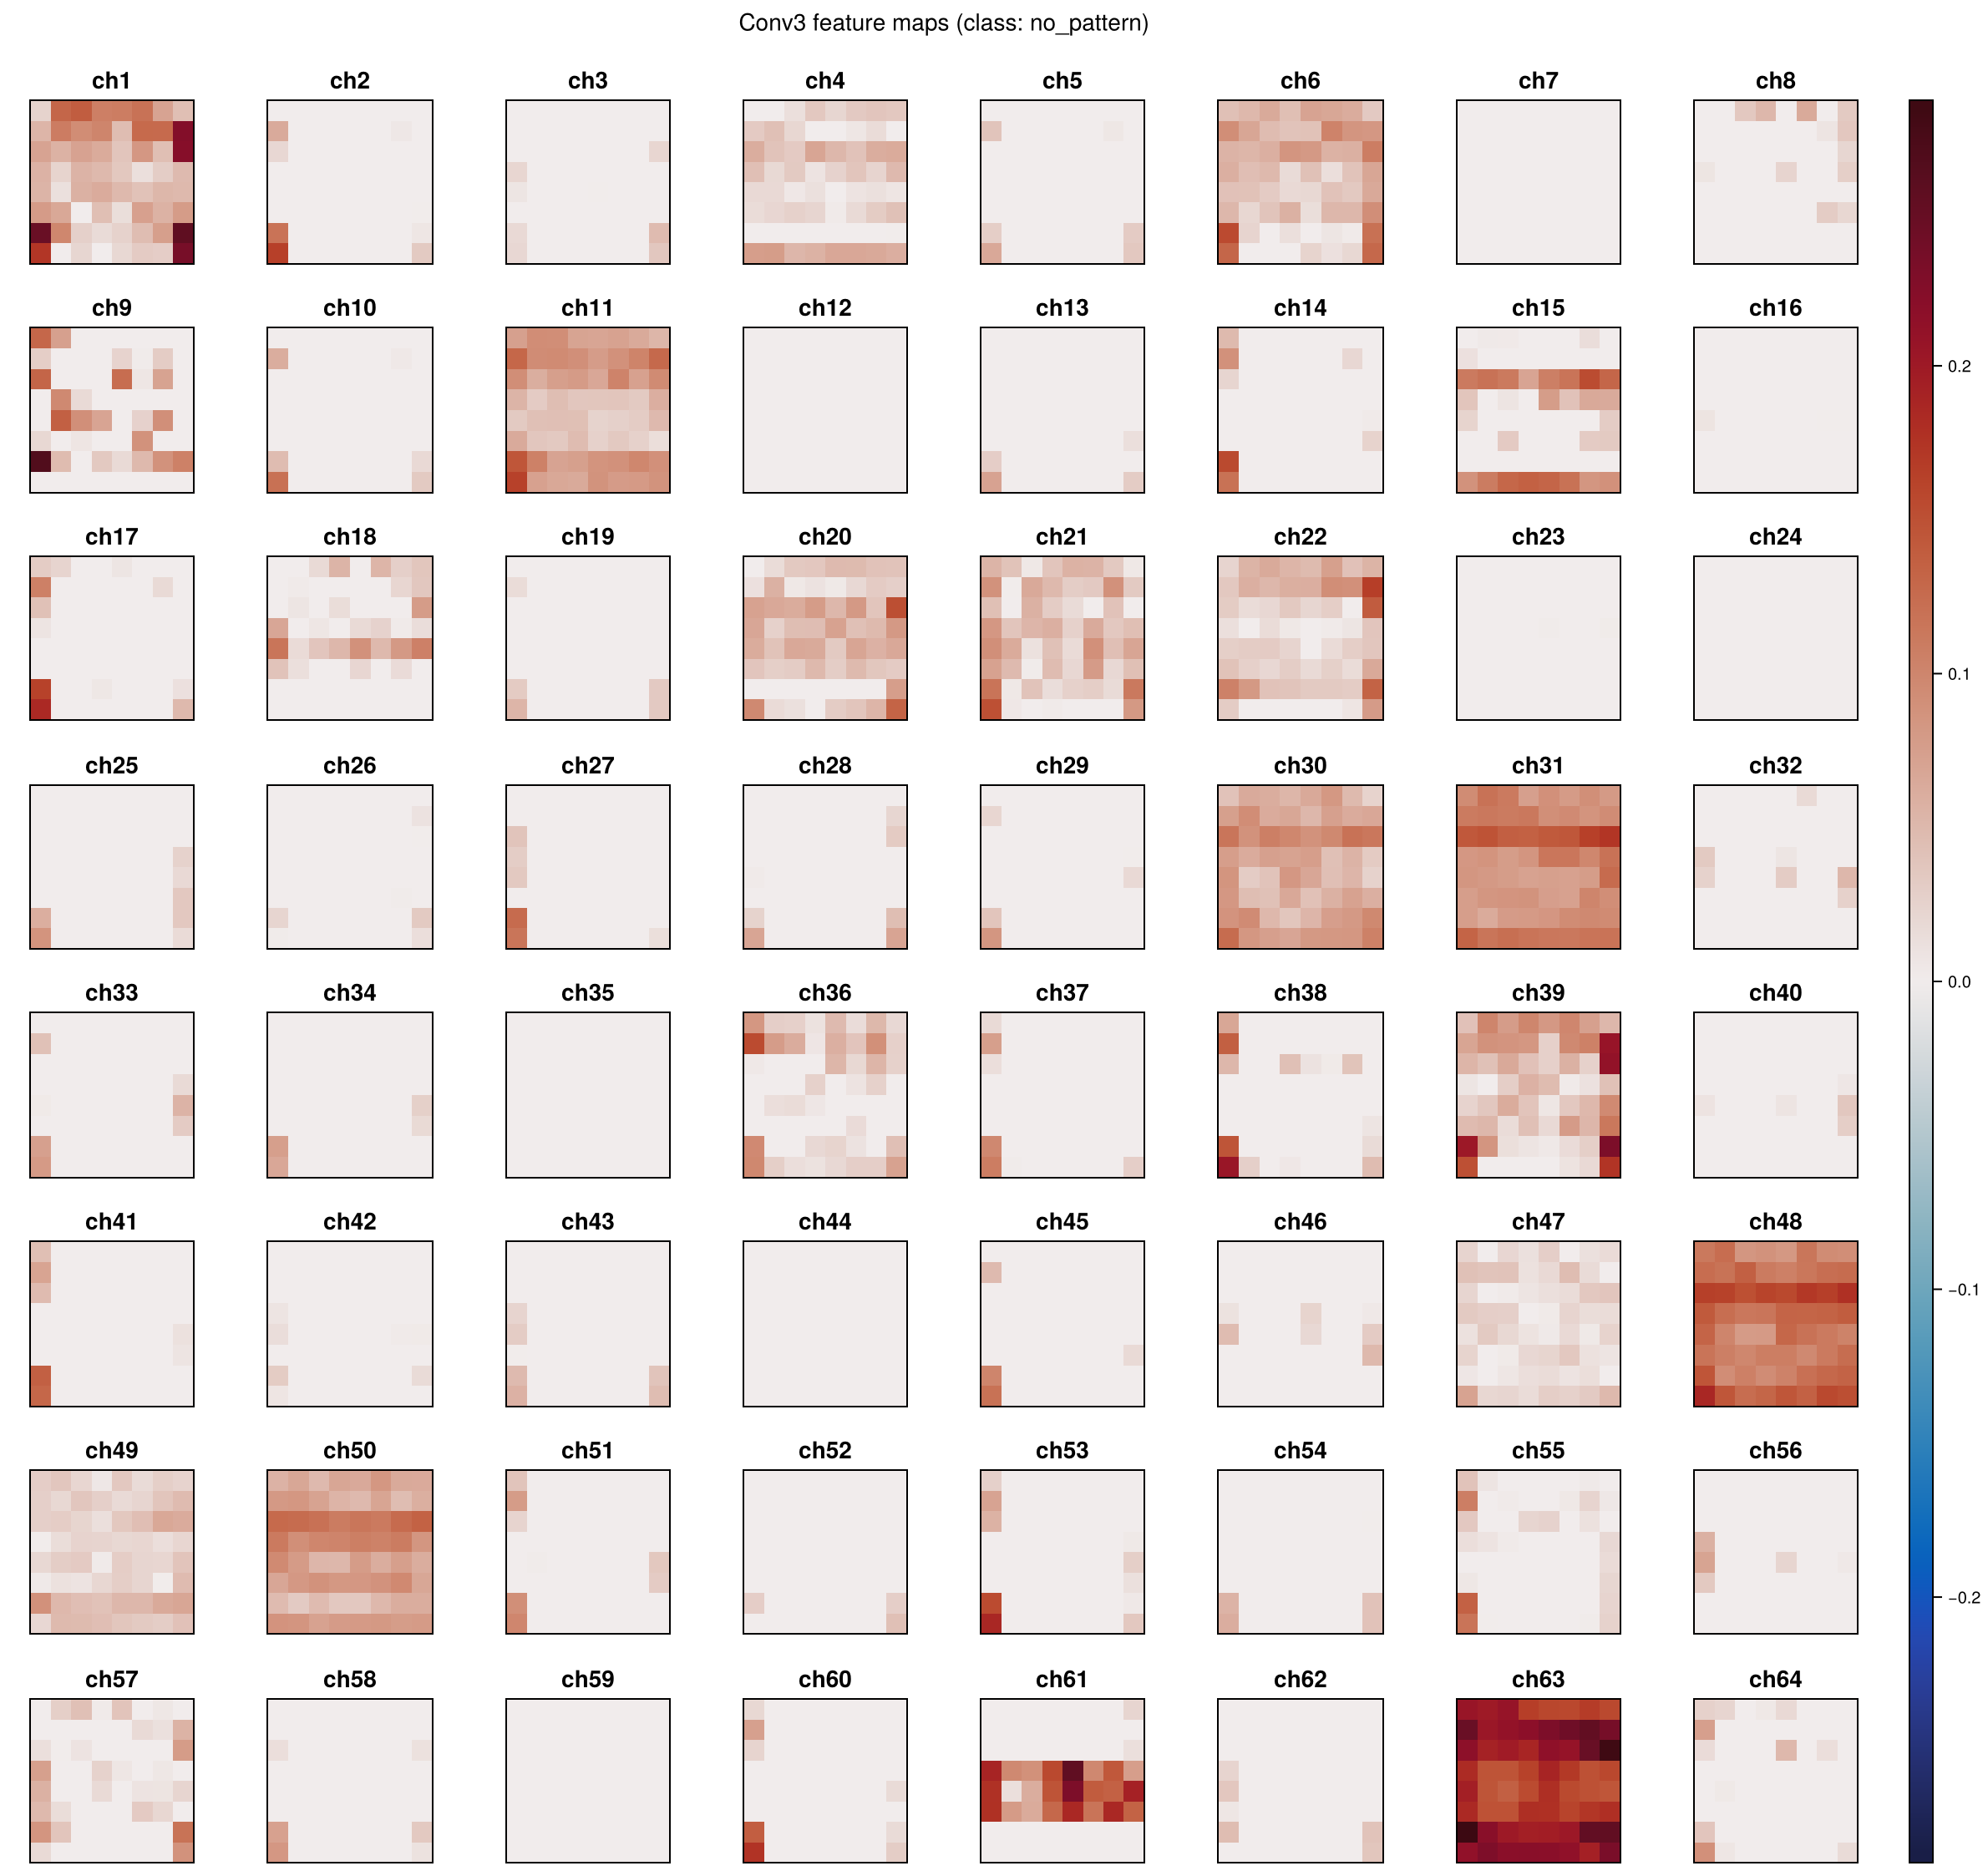

CairoMakie.Screen{IMAGE}


In [20]:
using CairoMakie

# Uses sample_idx, feat3, plot_feature_grid from the previous cell

display(plot_feature_grid(feat3; title="Conv3 feature maps (class: " * class_name * ")"))

In [21]:
using JLD2, Dates, Flux

model_dir = abspath(joinpath(pwd(), "..", "model_test"))
mkpath(model_dir)

stamp = Dates.format(now(), "yyyymmdd_HHMMSS")
model_path = joinpath(model_dir, "cnn_model_" * stamp * ".jld2")

model_cpu = cpu(model)

jldsave(model_path;
    model=model_cpu,
    model_state=Flux.state(model_cpu),
    pattern_names=pattern_names,
    variant_names=variant_names === nothing ? Symbol[] : variant_names,
    saved_at=stamp,
)

println("Saved model to: ", model_path)

Saved model to: /home/benjamin/Dokumente/BA2/notebooks/model_test/cnn_model_20260208_014145.jld2
